In [1]:
import warnings

warnings.filterwarnings("ignore")


In [2]:
# IMPORTS AND GLOBAL SETTINGS
import matplotlib.pyplot as plt
import polars as pl
from typing import Dict, Tuple

# ---------------------------
# Global style / constants
# ---------------------------
FIGSIZE = (6.685, 6.25)
DPI = 300

# Base font sizes
BASE_FONTSIZE = 17
TITLE_FONTSIZE = 20
TICK_FONTSIZE = 17
ANNOT_FONTSIZE = 17
COLORBAR_FONTSIZE = 17
MATH_FONTSIZE = 18

MARKER_SIZE = 36
ALPHA = 0.6
GRID_STYLE = {"linestyle": "--", "alpha": 0.3, "linewidth": 0.8}

# Define colors for consistency
primary_color = "#2E86AB"
secondary_color = "#A23B72"
accent_color = "#F18F01"
grid_color = "#E5E5E5"
success_color = "#27AE60"
warning_color = "#F39C12"
danger_color = "#E74C3C"
neutral_color = "#95A5A6"

# Vulnerability level colors
VULNERABILITY_COLORS = {
    "low": "#27AE60",
    "moderate": "#F39C12",
    "high": "#E67E22",
    "very_high": "#E74C3C",
}

# Apply consistent rcParams
plt.rcParams.update(
    {
        "figure.figsize": FIGSIZE,
        "figure.dpi": DPI,
        "savefig.dpi": DPI,
        "font.family": "DejaVu Sans",
        "font.size": BASE_FONTSIZE,
        "axes.titlesize": TITLE_FONTSIZE,
        "axes.labelsize": BASE_FONTSIZE,
        "xtick.labelsize": TICK_FONTSIZE,
        "ytick.labelsize": TICK_FONTSIZE,
        "legend.fontsize": BASE_FONTSIZE,
        "mathtext.fontset": "dejavusans",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
        "patch.linewidth": 1.0,
        "boxplot.flierprops.markersize": 4,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "text.usetex": False,
    }
)


# Utility functions for consistent plotting
def setup_academic_grid(ax, axis="both"):
    """Apply consistent grid styling to axes"""
    ax.grid(True, axis=axis, linestyle=":", linewidth=0.5, color=grid_color, alpha=0.7)


def add_vulnerability_zones(ax, axis="x", alpha=0.1):
    """Add vulnerability level background zones for SVI plots"""
    if axis == "x":
        ax.axvspan(
            0,
            0.25,
            alpha=alpha,
            color=VULNERABILITY_COLORS["low"],
            label="Low Vulnerability",
        )
        ax.axvspan(
            0.25,
            0.50,
            alpha=alpha,
            color=VULNERABILITY_COLORS["moderate"],
            label="Moderate Vulnerability",
        )
        ax.axvspan(
            0.50,
            0.75,
            alpha=alpha,
            color=VULNERABILITY_COLORS["high"],
            label="High Vulnerability",
        )
        ax.axvspan(
            0.75,
            1,
            alpha=alpha,
            color=VULNERABILITY_COLORS["very_high"],
            label="Very High Vulnerability",
        )
    elif axis == "y":
        ax.axhspan(0, 0.25, alpha=alpha, color=VULNERABILITY_COLORS["low"])
        ax.axhspan(0.25, 0.50, alpha=alpha, color=VULNERABILITY_COLORS["moderate"])
        ax.axhspan(0.50, 0.75, alpha=alpha, color=VULNERABILITY_COLORS["high"])
        ax.axhspan(0.75, 1, alpha=alpha, color=VULNERABILITY_COLORS["very_high"])


def savefig_standard(fname, dpi=None):
    """Save figure with consistent academic formatting"""
    if dpi is None:
        dpi = DPI
    plt.tight_layout()
    plt.savefig(
        fname,
        bbox_inches="tight",
        dpi=dpi,
        facecolor="white",
        edgecolor="none",
        transparent=False,
    )
    print(f"Saved: {fname}")


In [5]:
BASE_SAVE_DIR = "plots/evacuation_analytics"

In [17]:
def load_agent_traces(agent_summary: pl.DataFrame) -> Tuple[pl.DataFrame, Dict[str, list]]:
    """
    Load all agent traces from CSV files with robust coordinate handling.
    Extract original agent ID from filename and integrate with SVI data.

    Returns:
        Dictionary mapping agent IDs to their coordinate trajectories
    """

    print("Loading agent traces...")
    agent_traces = {}
    traces_loaded = 0
    expanded_agent_data = []

    try:
        trace_dir = "simulation_outcomes/agents_traces"
        if not os.path.exists(trace_dir):
            print(f"Trace directory {trace_dir} does not exist.")
            return agent_summary, agent_traces

        # Create a mapping from original agent ID to agent data
        agent_data_map = {}
        for row in agent_summary.iter_rows(named=True):
            agent_data_map[row['agent_id']] = row

        # Get all trace files
        trace_files = [f for f in os.listdir(trace_dir) if f.endswith('.csv')]

        for trace_file in trace_files:
            try:
                # Extract original agent ID from filename
                filename_without_ext = trace_file.replace(".csv", "")
                parts = filename_without_ext.split("_")
                original_agent_id = "_".join(parts[:-1])  # Remove the trailing index

                # Get agent data from the mapping
                if original_agent_id not in agent_data_map:
                    print(
                        f"Original agent ID {original_agent_id} not found in summary data for trace file {trace_file}")
                    continue

                agent_data = agent_data_map[original_agent_id]

                trace_path = os.path.join(trace_dir, trace_file)
                df = pl.read_csv(trace_path)

                if df.is_empty():
                    continue

                # Extract coordinates - simulation uses y=lat, x=lon
                coordinates = []
                for row in df.iter_rows(named=True):
                    if row["y"] is not None and row["x"] is not None:
                        coordinates.append(
                            [float(row["y"]), float(row["x"])]
                        )  # [lat, lon]

                if len(coordinates) >= 2:
                    # Use the trace filename as the unique agent ID
                    unique_agent_id = filename_without_ext
                    agent_traces[unique_agent_id] = coordinates

                    # Create expanded agent data with the unique ID
                    expanded_agent = dict(agent_data)
                    expanded_agent['agent_id'] = unique_agent_id
                    expanded_agent['original_agent_id'] = original_agent_id
                    expanded_agent_data.append(expanded_agent)

                    traces_loaded += 1

            except Exception as e:
                print(f"Error loading trace for file {trace_file}: {e}")

        # Create a new agent summary with the expanded data
        if expanded_agent_data:
            expanded_agent_summary = pl.DataFrame(expanded_agent_data)
        else:
            expanded_agent_summary = agent_summary

        print(
            f"Successfully loaded traces for {traces_loaded} out of {len(trace_files)} trace files"
        )

    except Exception as e:
        print(f"Error processing agent traces: {e}")
        expanded_agent_summary = agent_summary

    return expanded_agent_summary, agent_traces


def load_simulation_data() -> Tuple[pl.DataFrame, pl.DataFrame, Dict[str, list]]:
    """Load all simulation outcome data"""
    print("Loading simulation data...")

    # Load agent summary statistics
    agent_summary = pl.read_csv("simulation_outcomes/Agents_Statistics_Trial.csv")

    # Load journey segment details if available
    journey_segments_path = "simulation_outcomes/Journey_Segments_Detail.csv"
    if os.path.exists(journey_segments_path):
        journey_segments = pl.read_csv(journey_segments_path)
    else:
        journey_segments = pl.DataFrame()

    # Load agent traces and get expanded agent summary
    agent_summary, agent_traces = load_agent_traces(agent_summary)

    return agent_summary, journey_segments, agent_traces


def preprocess_data(
        agent_summary: pl.DataFrame, journey_segments: pl.DataFrame
) -> Tuple[pl.DataFrame, pl.DataFrame]:
    """
    Clean and preprocess the data for analysis

    Args:
        agent_summary: Raw agent summary data
        journey_segments: Raw journey segments data

    Returns:
        Preprocessed agent summary and journey segments
    """
    # Convert SVI to categorical vulnerability levels
    agent_summary = agent_summary.with_columns(
        pl.when(pl.col("svi") <= 0.25)
        .then(pl.lit("low"))
        .when(pl.col("svi") <= 0.5)
        .then(pl.lit("moderate"))
        .when(pl.col("svi") <= 0.75)
        .then(pl.lit("high"))
        .otherwise(pl.lit("very_high"))
        .alias("vulnerability_level")
    )

    # Ensure evacuation time is in minutes
    if "evacuation_time_seconds" in agent_summary.columns:
        agent_summary = agent_summary.with_columns(
            (pl.col("evacuation_time_seconds") / 60).alias("evacuation_time_minutes")
        )

    # Categorize success
    agent_summary = agent_summary.with_columns(
        (pl.col("status") == "ARRIVED").alias("success")
    )

    # Identify public transport users more accurately
    if "used_public_transport" not in agent_summary.columns:
        # Check if agent has journey segments
        if "agent_id" in journey_segments.columns and not journey_segments.is_empty():
            # Use the original agent ID for matching
            if "original_agent_id" in agent_summary.columns:
                pt_users = journey_segments["agent_id"].unique()
                agent_summary = agent_summary.with_columns(
                    pl.col("original_agent_id").is_in(pt_users).alias("used_public_transport")
                )
            else:
                pt_users = journey_segments["agent_id"].unique()
                agent_summary = agent_summary.with_columns(
                    pl.col("agent_id").is_in(pt_users).alias("used_public_transport")
                )
        else:
            agent_summary = agent_summary.with_columns(
                pl.lit(False).alias("used_public_transport")
            )

    return agent_summary, journey_segments


# Load and preprocess data
agent_summary, journey_segments, agent_traces = load_simulation_data()
agent_summary, journey_segments = preprocess_data(agent_summary, journey_segments)


Loading simulation data...
Loading agent traces...
Original agent ID 42_0586 not found in summary data for trace file 42_0586_475.csv
Original agent ID 42_0586 not found in summary data for trace file 42_0586_476.csv
Successfully loaded traces for 1064 out of 1066 trace files


In [18]:
agent_summary = agent_summary.with_columns(
    pl.col("final_mode").replace("CAR", "Motor_Powered_Vehicle").alias("final_mode")
)


Starting Evacuation Analysis...
=== EVACUATION SIMULATION SUMMARY STATISTICS ===

Total Agents: 1,064

Status Distribution:
  EVACUATING: 956 (89.8%)
  ARRIVED: 66 (6.2%)
  FAILED: 42 (3.9%)

Vulnerability Level Distribution:
  moderate: 536 (50.4%)
  high: 456 (42.9%)
  low: 52 (4.9%)
  very_high: 20 (1.9%)

Distance Statistics:
  Mean Distance: 15000m
  Median Distance: 10897m
  Std Distance: 9362m
  Max Distance: 56067m

Evacuation Time Statistics:
  Mean Time: 168.3 minutes
  Median Time: 180.0 minutes
  Max Time: 180.0 minutes

Transportation Mode Distribution:
  Motor_Powered_Vehicle: 360 (33.8%)
  BIKE: 91 (8.6%)
  WALKING: 613 (57.6%)

Public Transport Usage: 59.7%

Transportation Mode and Public Transport Combination:
  WALKING with PT: 554 (52.1%)
  BIKE with PT: 81 (7.6%)
  Motor_Powered_Vehicle without PT: 360 (33.8%)
  BIKE without PT: 10 (0.9%)
  WALKING without PT: 59 (5.5%)

Generating visualizations...
Saved: svi_quartile_distribution.png


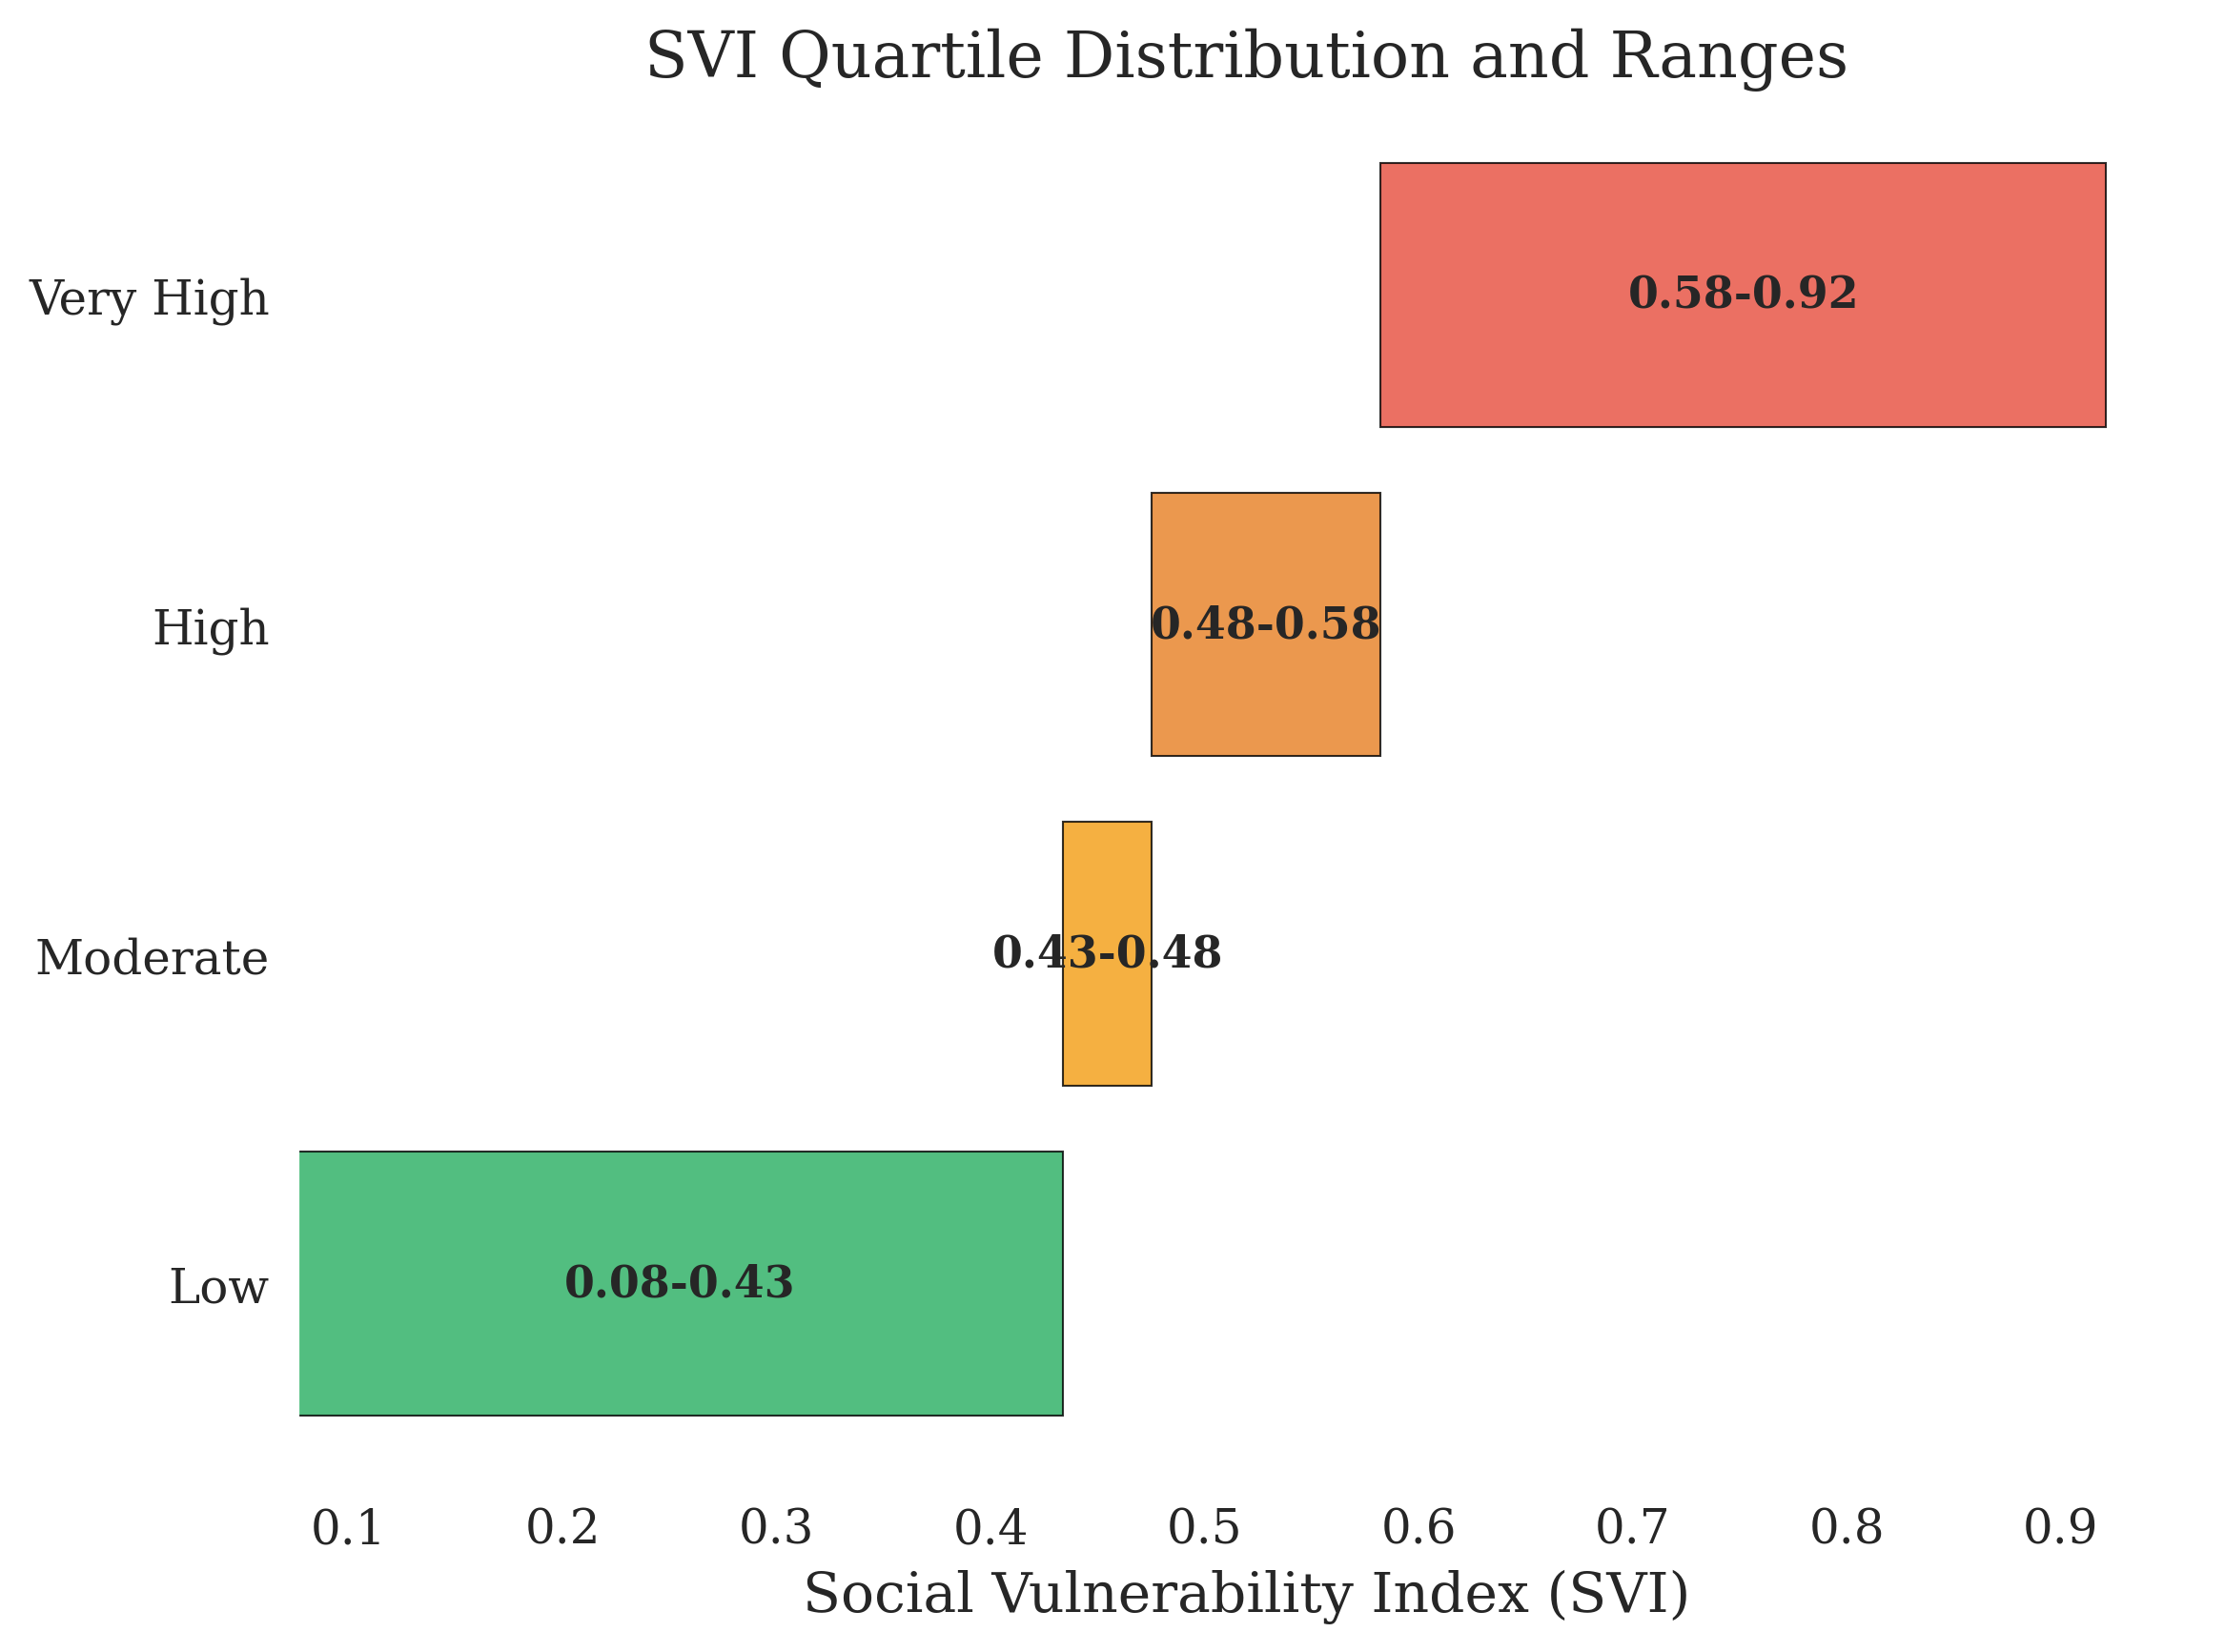


=== SVI QUARTILE INFORMATION ===
Minimum SVI: 0.0760
Q1 (25th percentile): 0.4338
Q2 (Median): 0.4752
Q3 (75th percentile): 0.5822
Maximum SVI: 0.9210

Vulnerability Level Ranges:
  Low: 0.0760 - 0.4338 (266 agents)
  Moderate: 0.4338 - 0.4752 (262 agents)
  High: 0.4752 - 0.5822 (269 agents)
  Very_High: 0.5822 - 0.9210 (263 agents)
Saved: distance_by_vulnerability.png


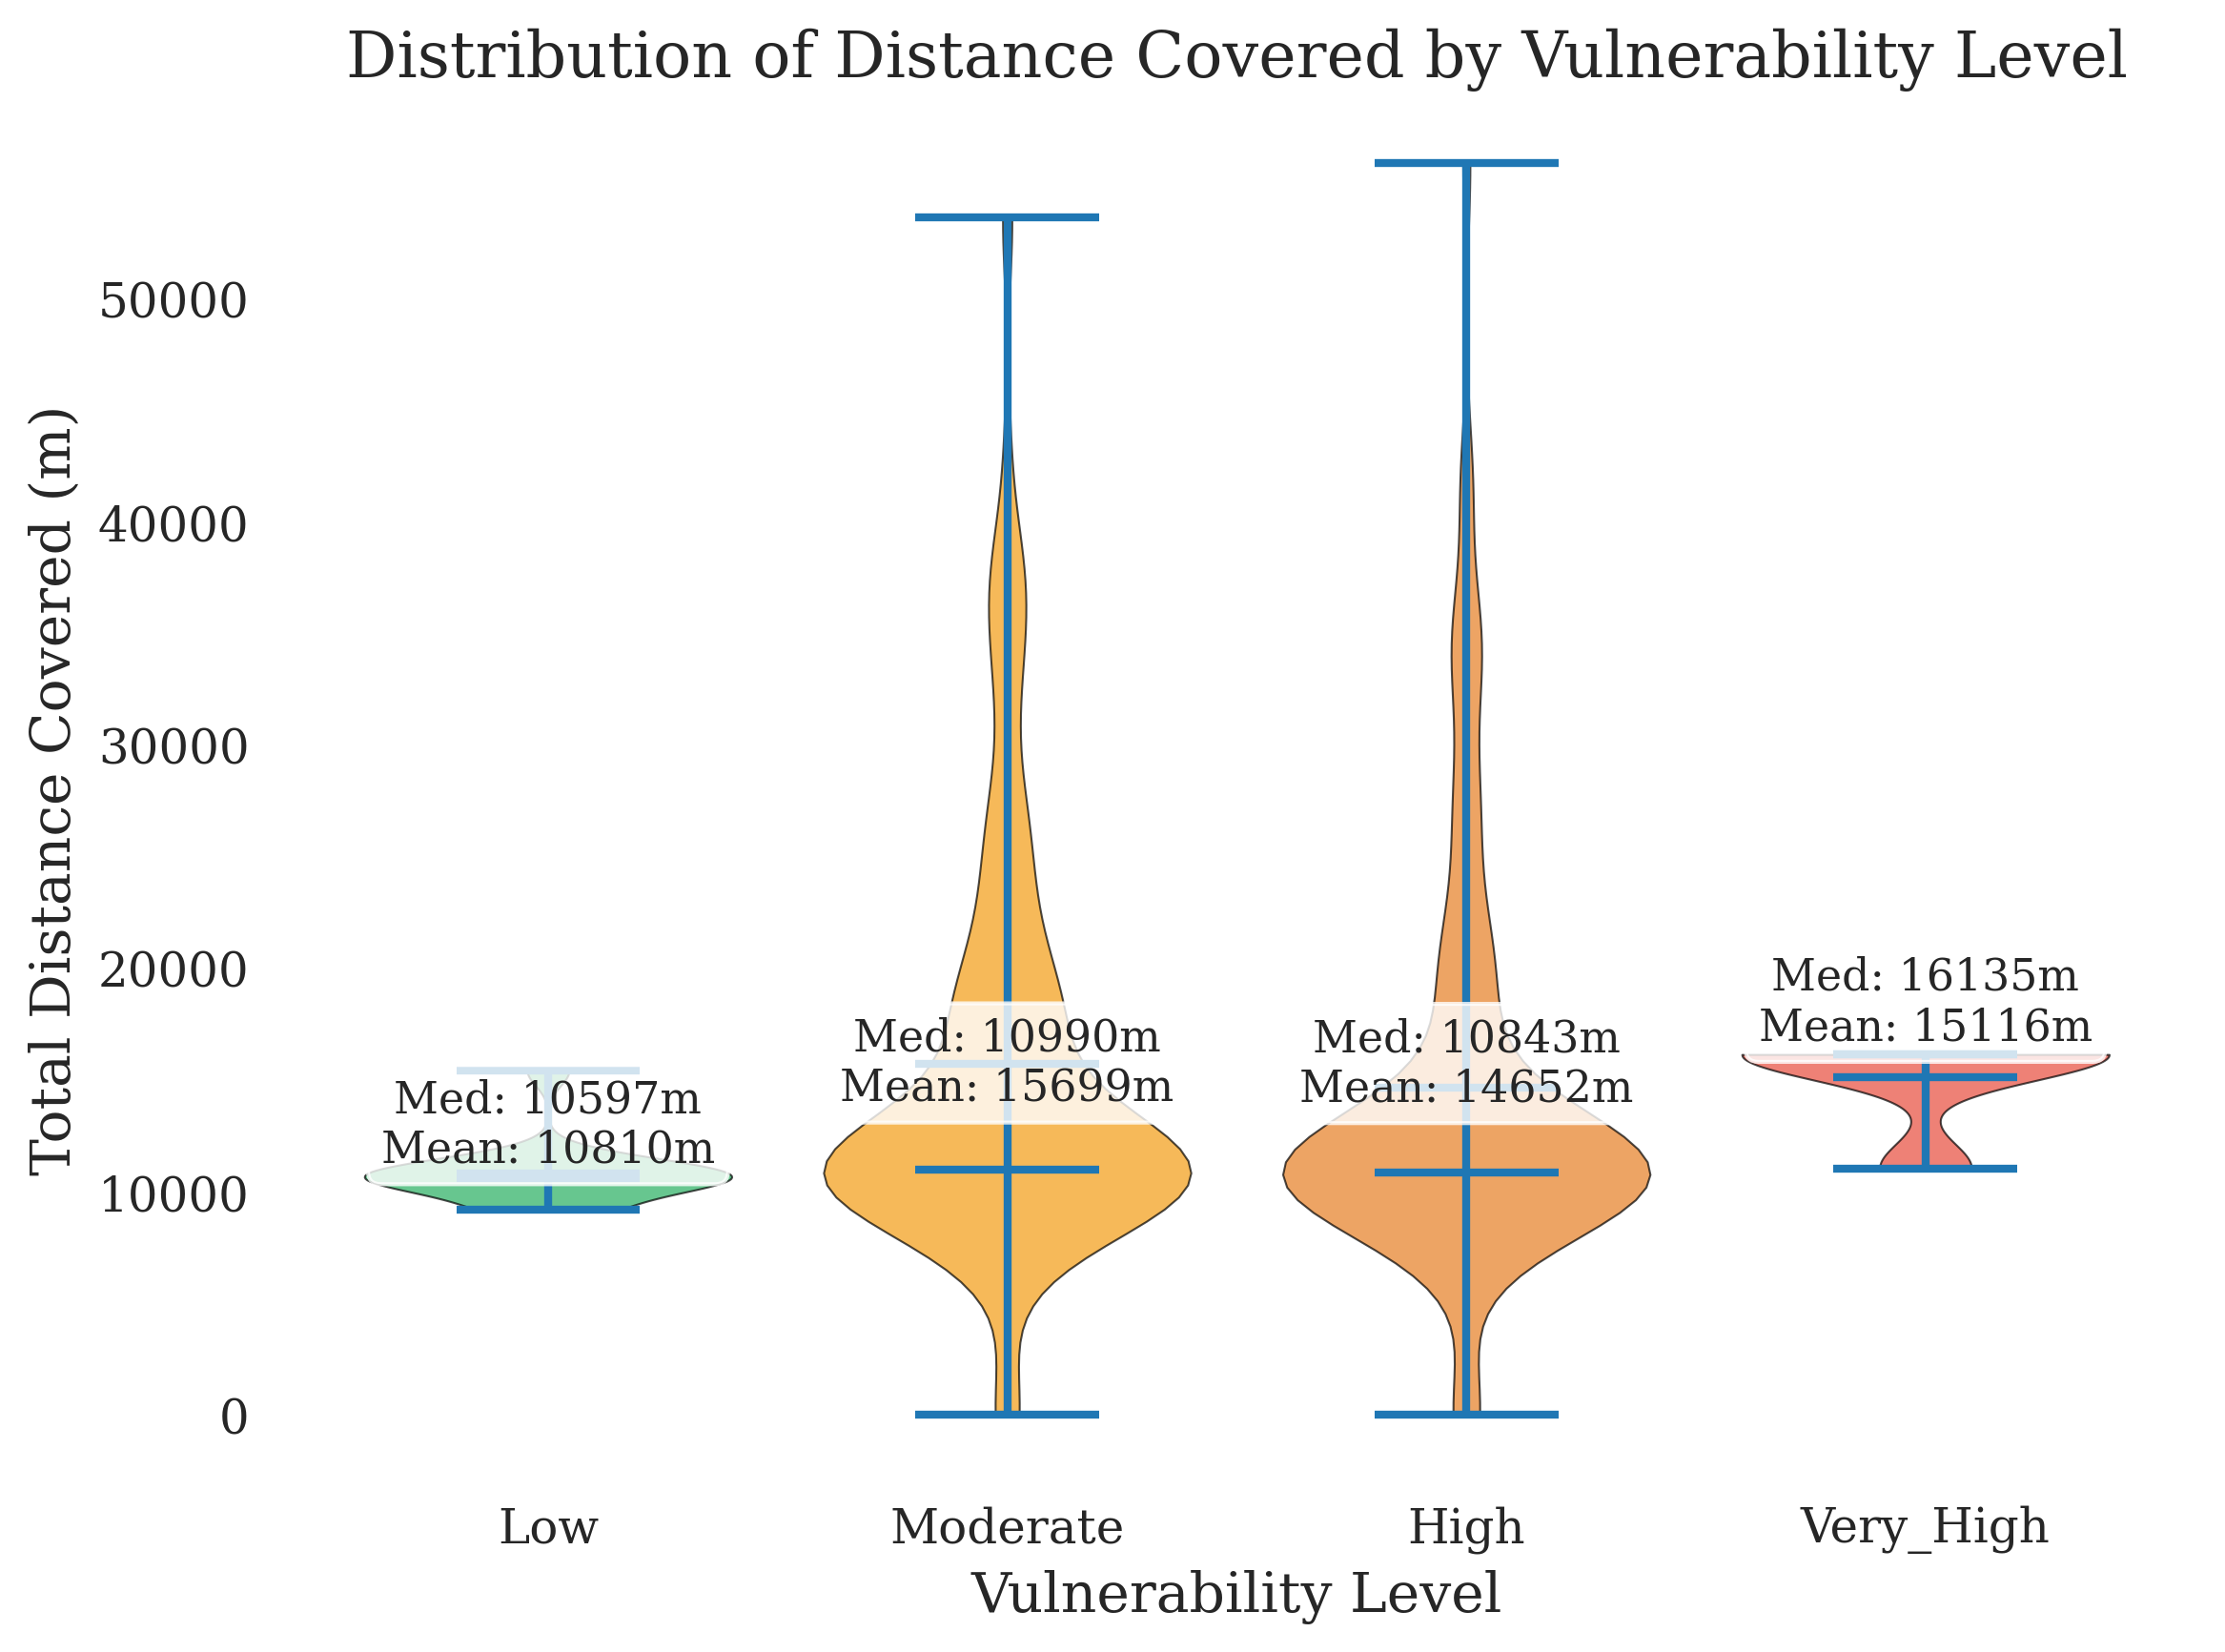

Saved: evacuation_status_by_vulnerability.png


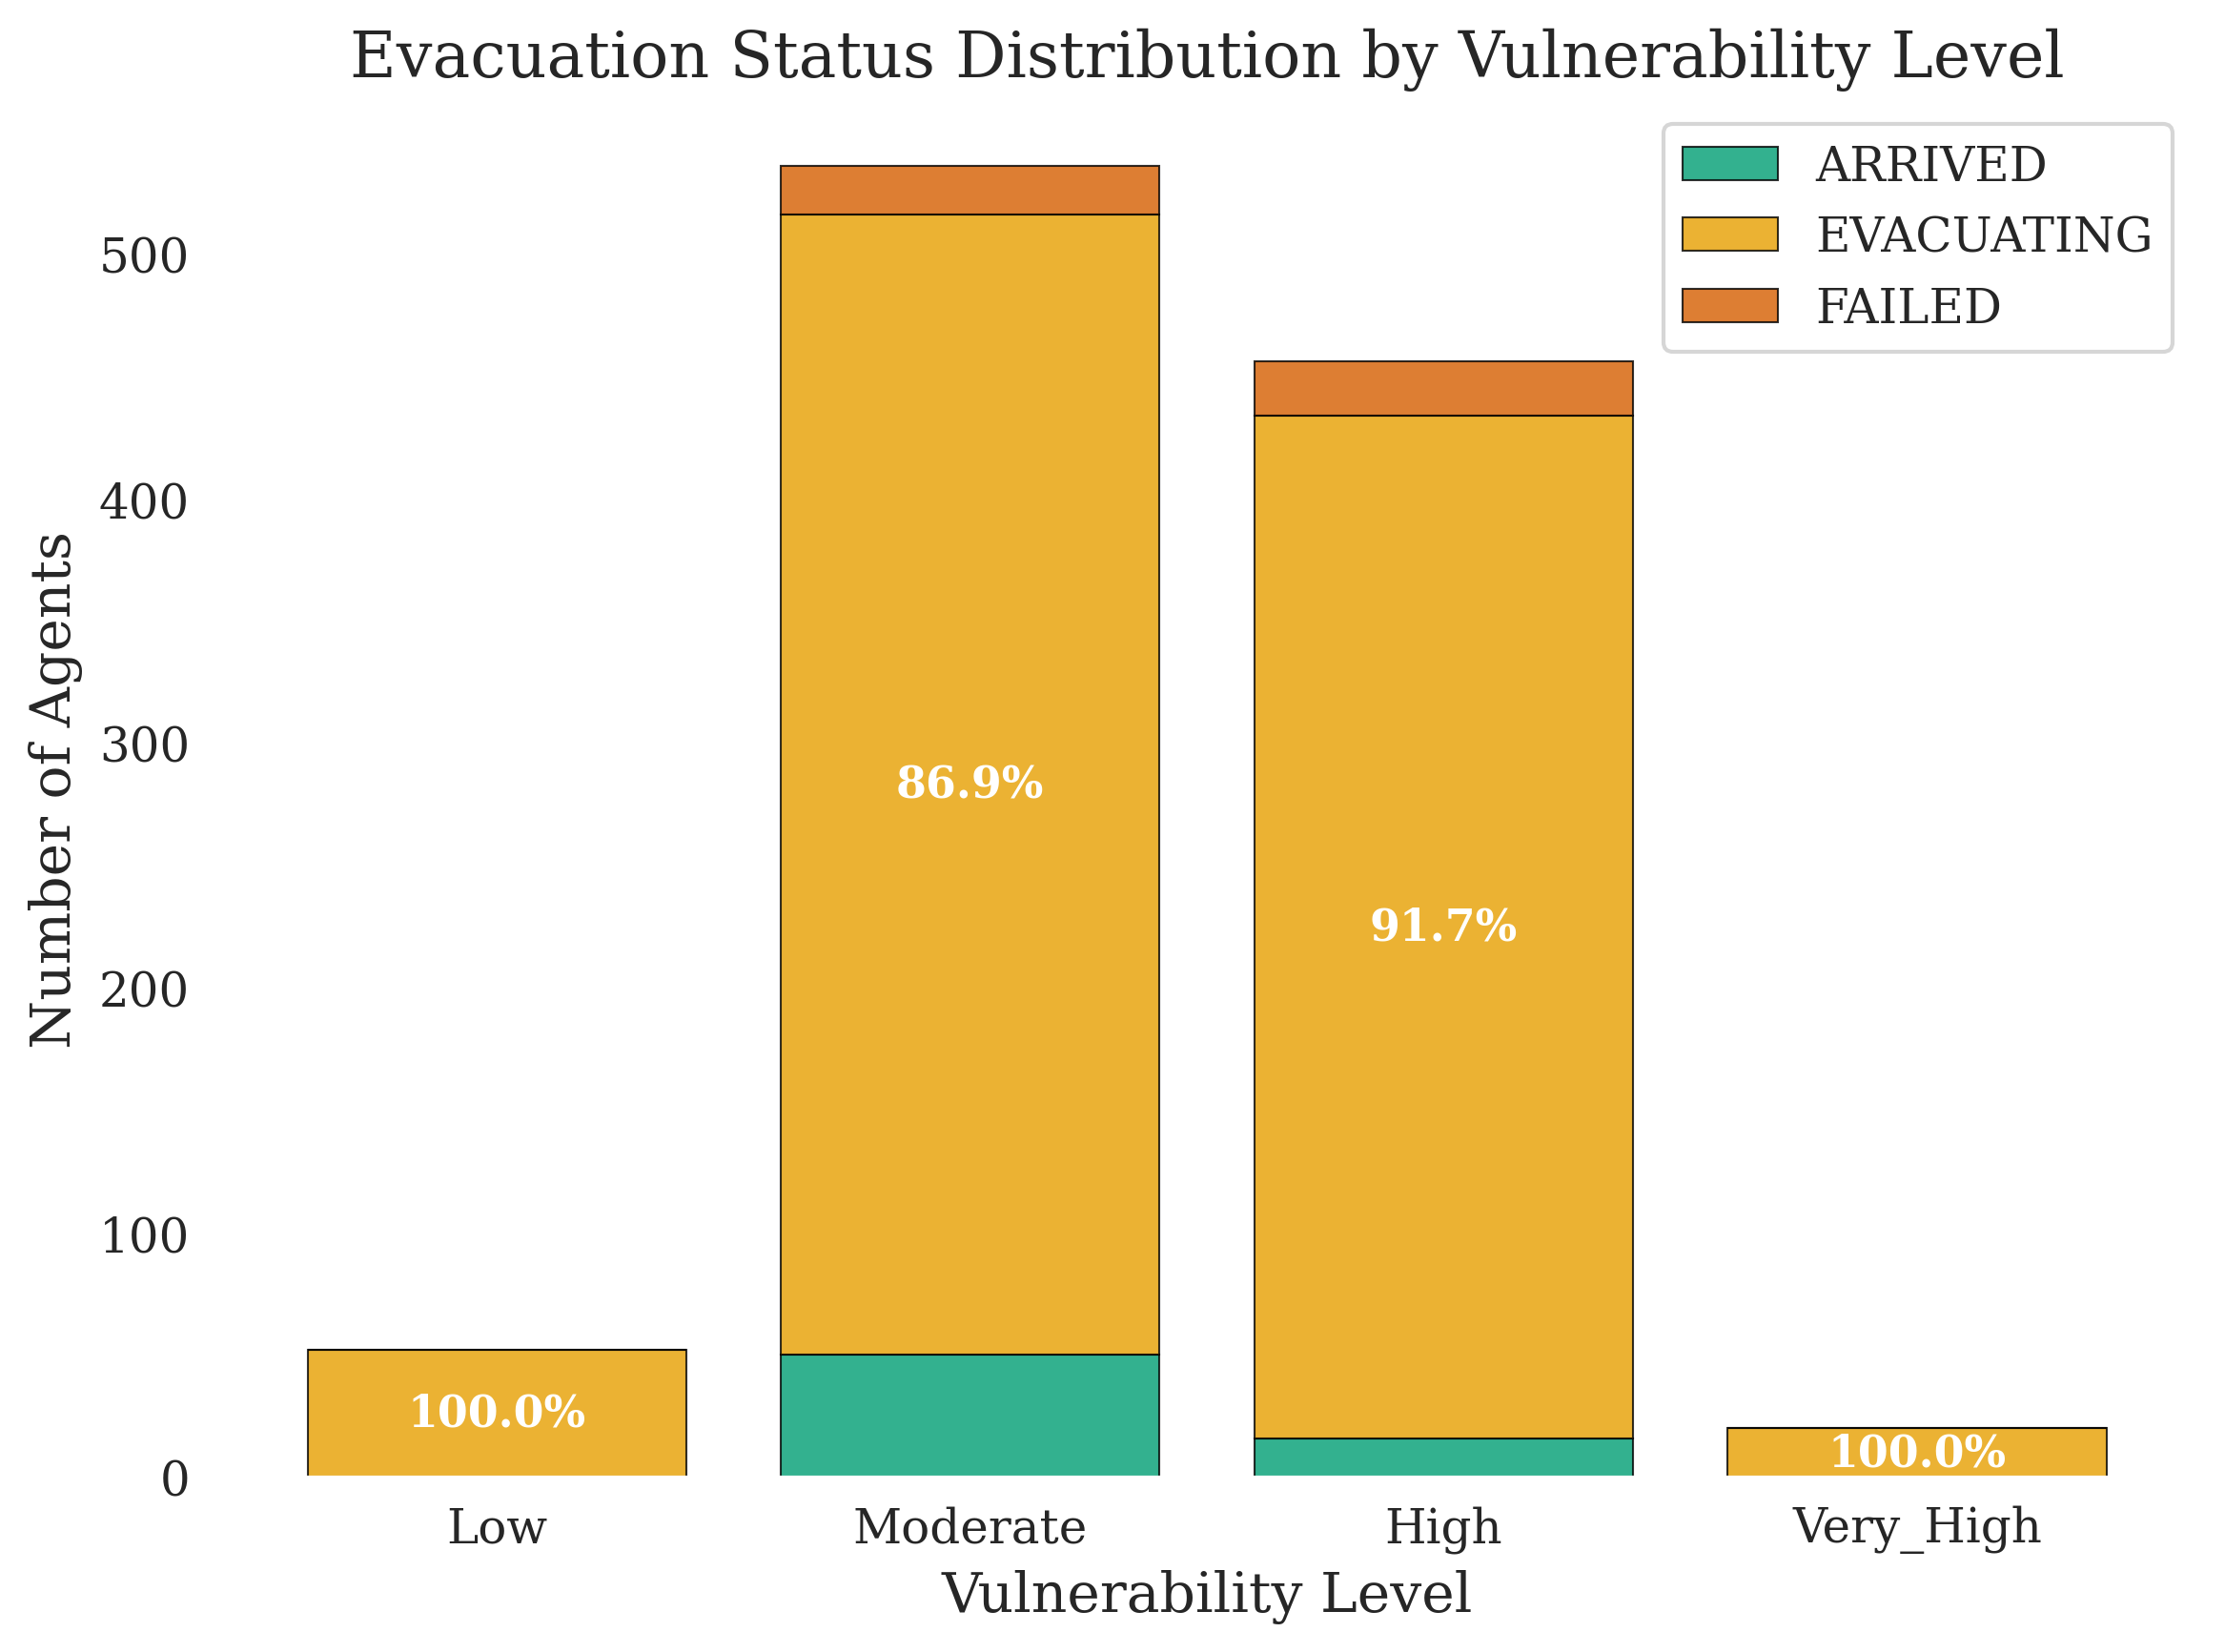

Saved: distance_comparison_scatter.png


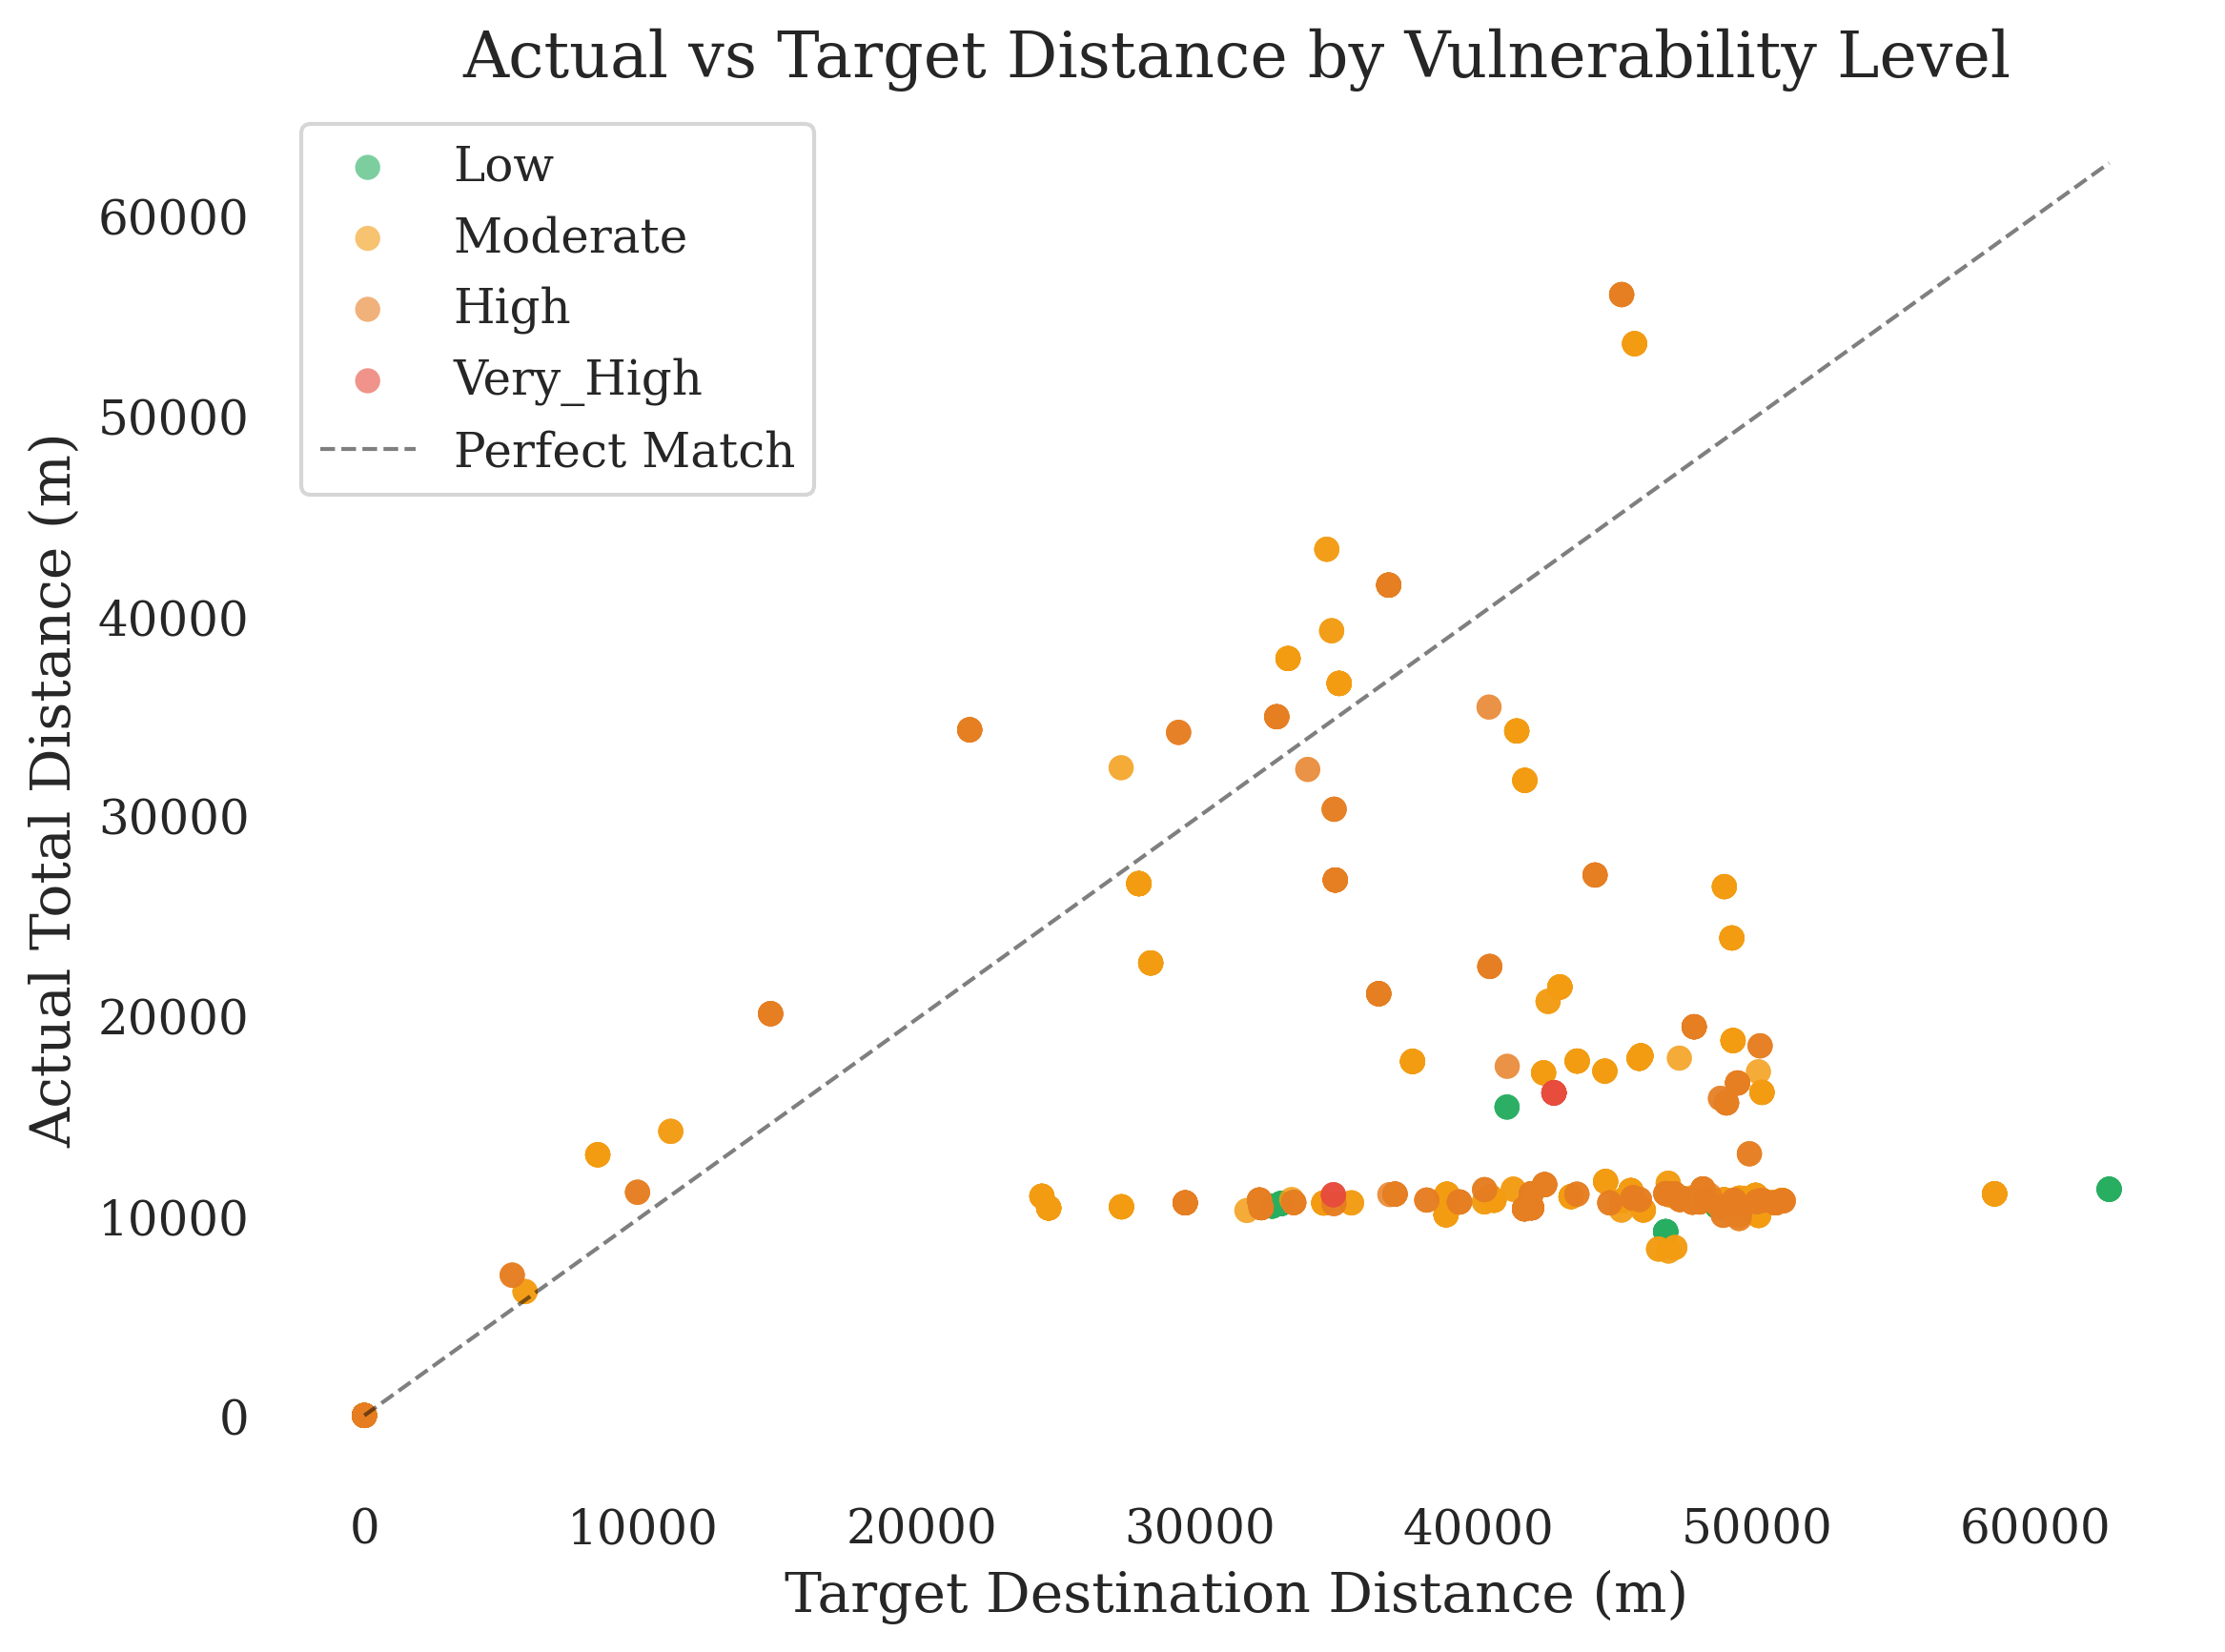

Saved: evacuation_time_by_vulnerability.png


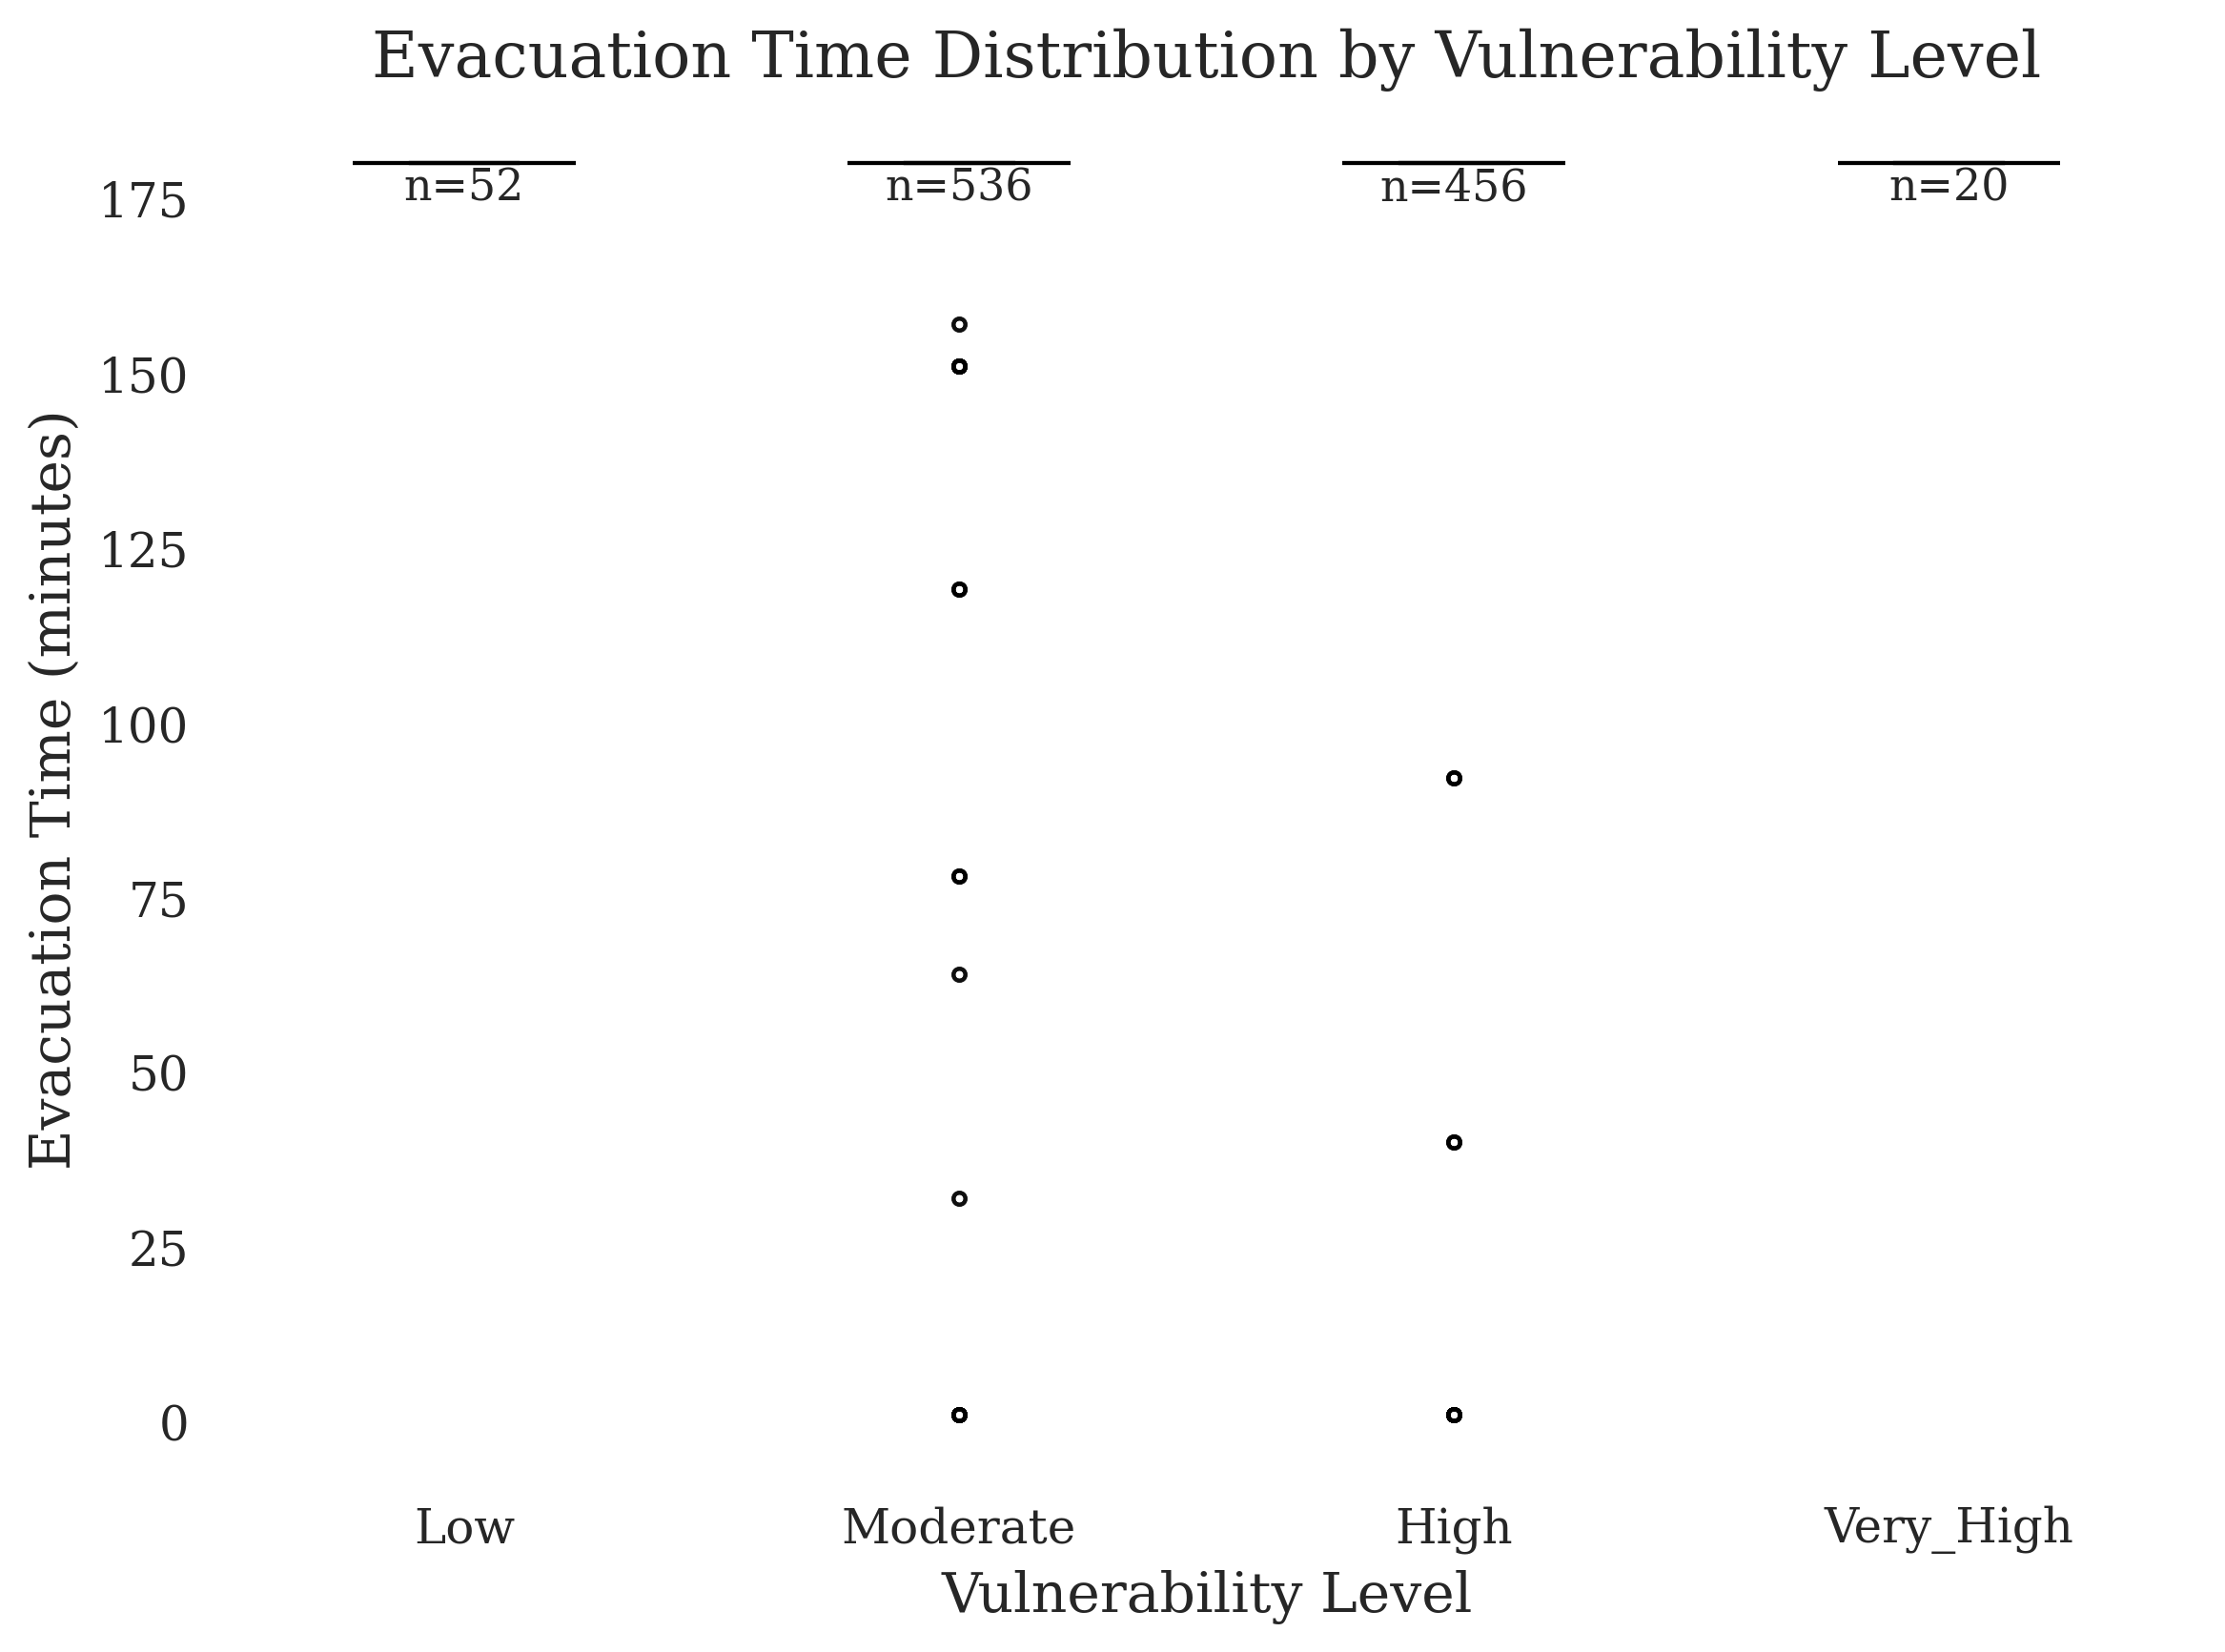

Saved: transportation_mode_by_vulnerability.png


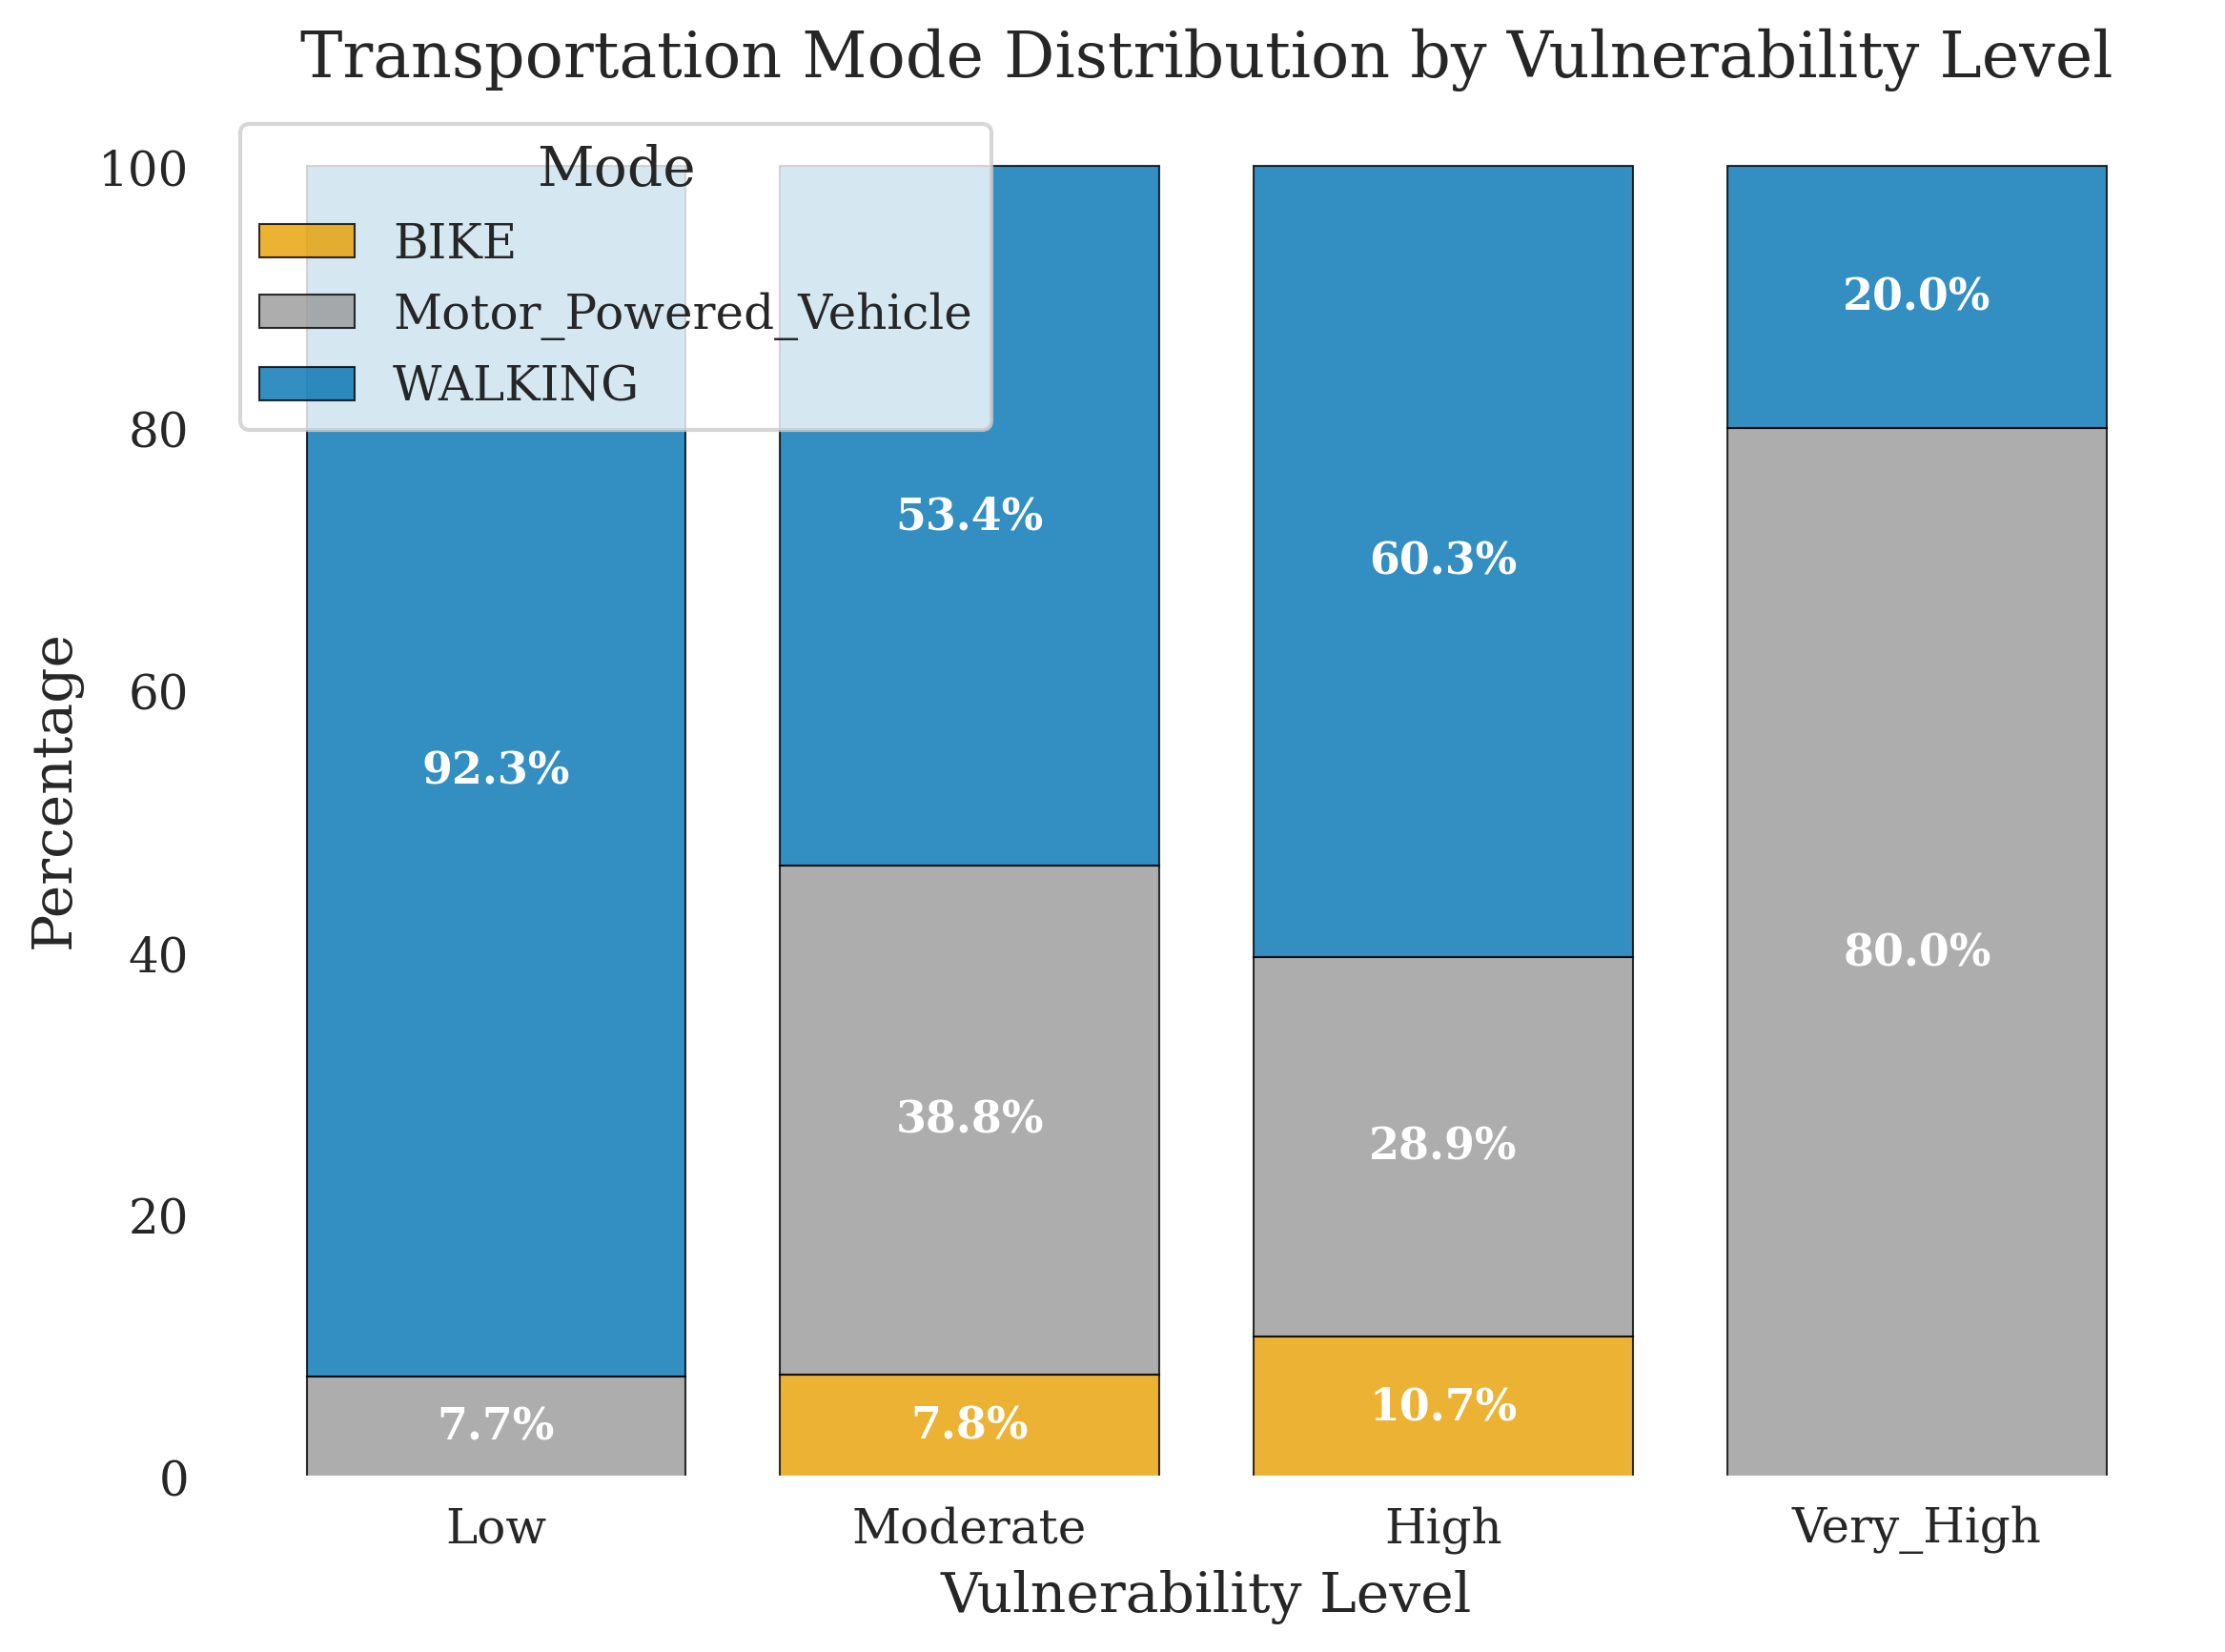

Saved: public_transport_usage.png


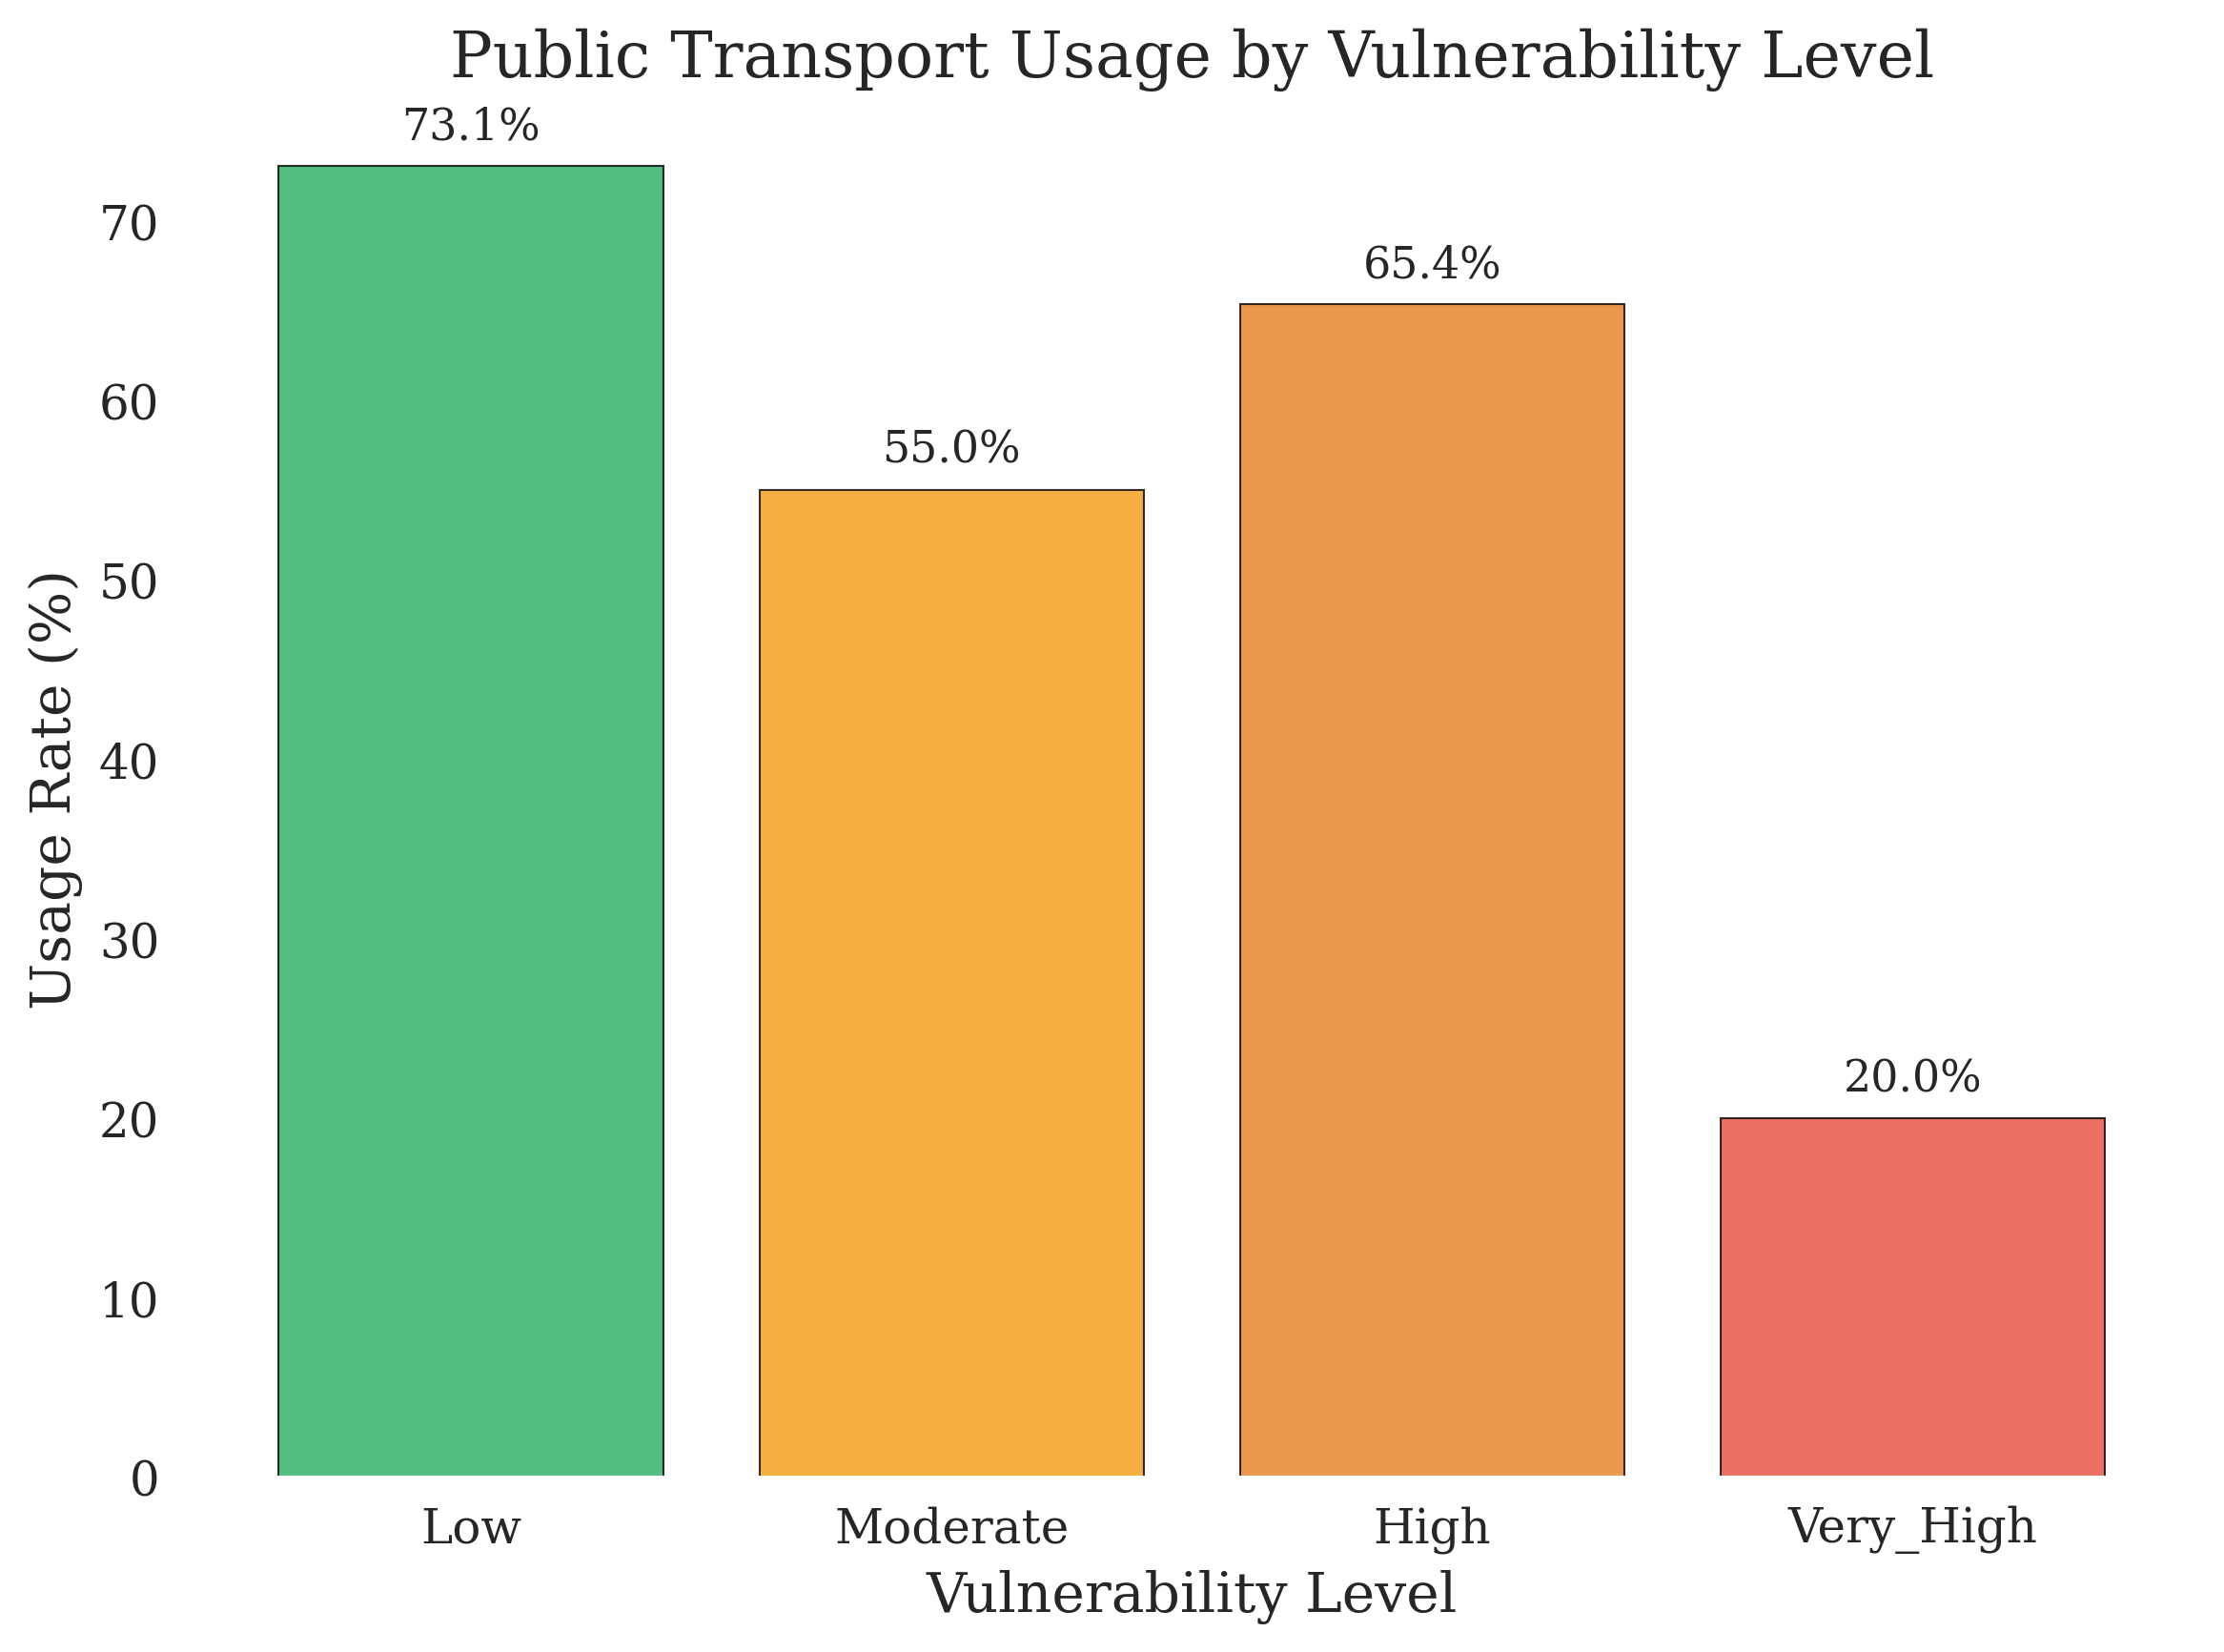

Saved: transportation_mode_pt_combination.png


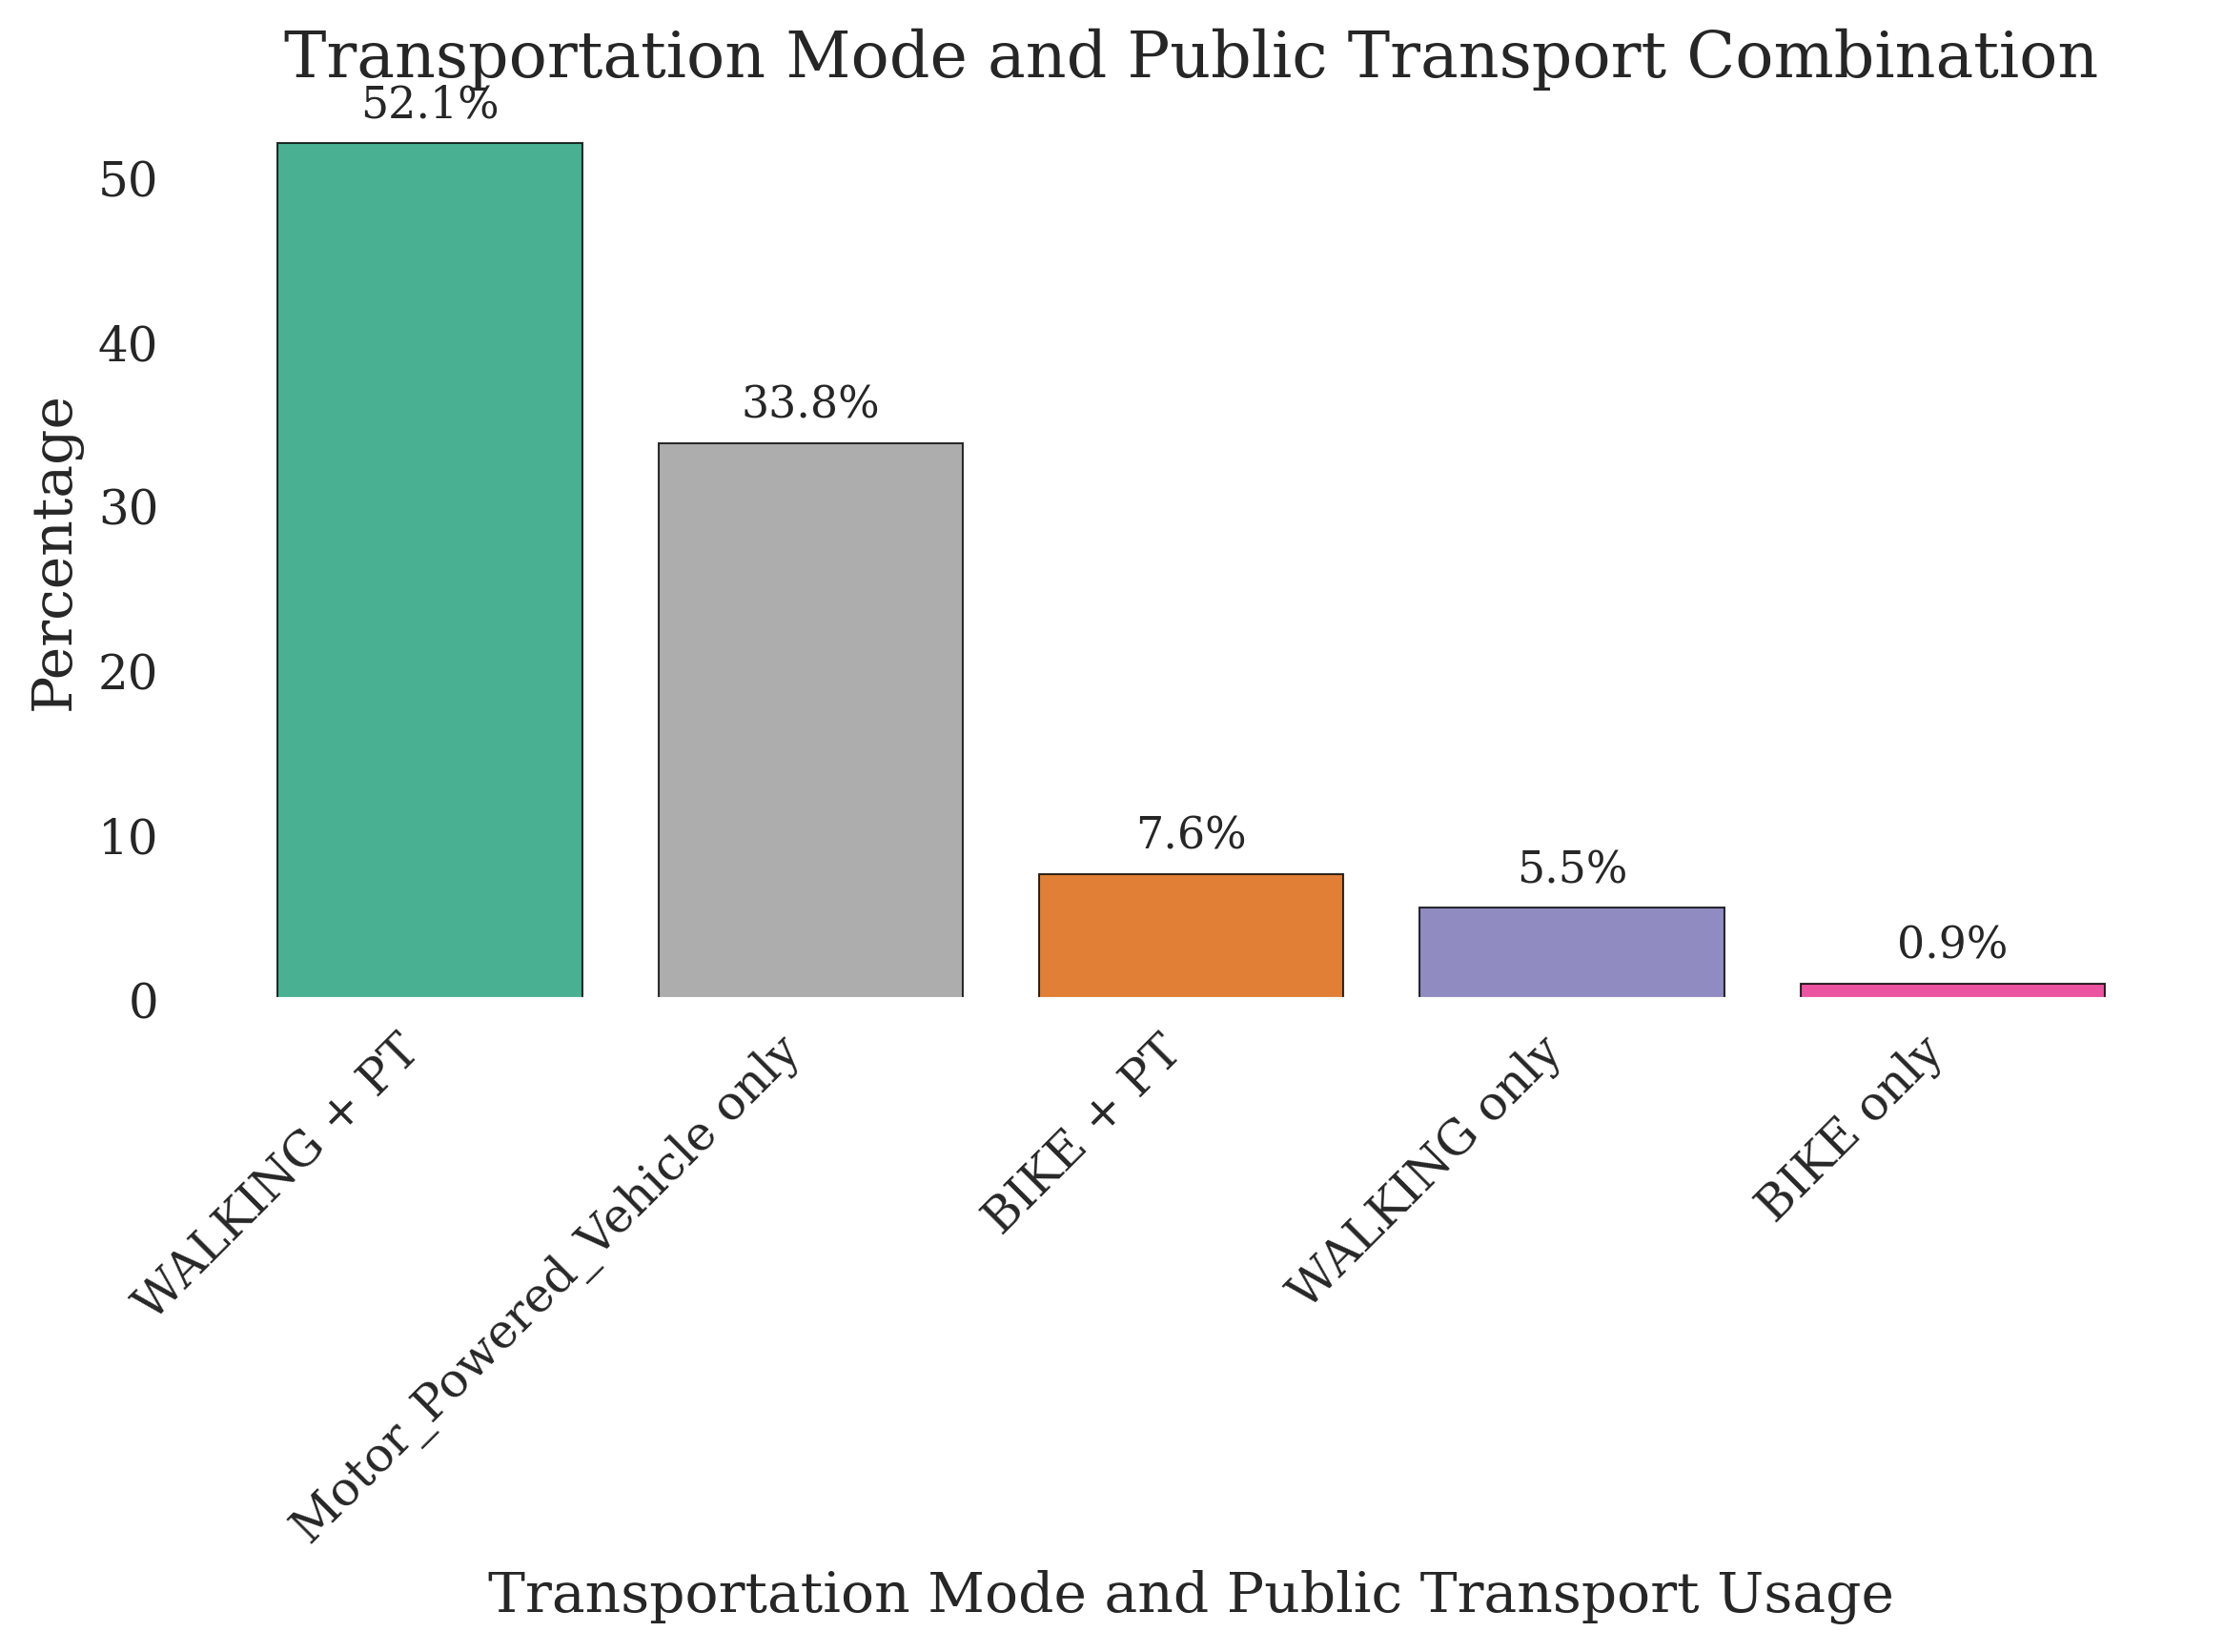


Analysis complete! All visualizations have been saved.


In [19]:
# IMPORTS AND GLOBAL SETTINGS
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import polars as pl
import os
from typing import Optional

# ---------------------------
# Global style / constants
# ---------------------------
FIGSIZE = (8, 6)  # Slightly larger for better readability
DPI = 300  # Higher DPI for publication quality

# Font sizes optimized for publication
BASE_FONTSIZE = 14
TITLE_FONTSIZE = 16
TICK_FONTSIZE = 12
ANNOT_FONTSIZE = 11
LEGEND_FONTSIZE = 12

MARKER_SIZE = 40
ALPHA = 0.7
GRID_STYLE = {"linestyle": ":", "alpha": 0.3, "linewidth": 0.5}

# Define colors for consistency (colorblind friendly)
primary_color = "#0072B2"  # Blue
secondary_color = "#E69F00"  # Orange
accent_color = "#009E73"  # Green
grid_color = "#D3D3D3"
success_color = "#009E73"  # Green
warning_color = "#E69F00"  # Orange
danger_color = "#D55E00"  # Red
neutral_color = "#999999"  # Gray

# Vulnerability level colors
VULNERABILITY_COLORS = {
    "low": "#27AE60",
    "moderate": "#F39C12",
    "high": "#E67E22",
    "very_high": "#E74C3C",
}
# Apply consistent rcParams
plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "mathtext.fontset": "dejavusans",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "grid.linewidth": 0.5,
    "lines.linewidth": 2.0,
    "patch.linewidth": 1.0,
    "boxplot.flierprops.markersize": 3,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.usetex": False,
})


# Utility functions for consistent plotting
def setup_academic_grid(ax, axis="both"):
    """Apply consistent grid styling to axes"""
    ax.grid(True, axis=axis, **GRID_STYLE)


def savefig_standard(fname, dpi=None, bbox_inches="tight"):
    """Save figure with consistent academic formatting"""
    if dpi is None:
        dpi = DPI
    plt.tight_layout()
    plt.savefig(
        f"plots/evacuation_analytics/{fname}",
        bbox_inches=bbox_inches,
        dpi=dpi,
        facecolor="white",
        edgecolor="none",
        transparent=False,
    )
    print(f"Saved: {fname}")


# ===========================
# ANALYSIS FUNCTIONS
# ===========================

def create_vulnerability_quantiles(df):
    """Create vulnerability level categories based on SVI quartiles"""
    # Calculate quartiles individually
    q1 = df.select(pl.col('svi').quantile(0.25)).item()
    q2 = df.select(pl.col('svi').quantile(0.50)).item()
    q3 = df.select(pl.col('svi').quantile(0.75)).item()

    quantiles = [q1, q2, q3]
    print(f"SVI Quartiles: {quantiles}")

    # Create vulnerability levels
    df_with_vuln = df.with_columns([
        pl.when(pl.col('svi') <= q1)
        .then(pl.lit('low'))
        .when(pl.col('svi') <= q2)
        .then(pl.lit('moderate'))
        .when(pl.col('svi') <= q3)
        .then(pl.lit('high'))
        .otherwise(pl.lit('very_high'))
        .alias('vulnerability_level')
    ])

    return df_with_vuln


def plot_svi_quartile_distribution(df):
    """Plot SVI quartile distribution with ranges"""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Calculate quartiles individually
    q1 = df.select(pl.col('svi').quantile(0.25)).item()
    q2 = df.select(pl.col('svi').quantile(0.50)).item()
    q3 = df.select(pl.col('svi').quantile(0.75)).item()
    svi_min = df['svi'].min()
    svi_max = df['svi'].max()

    # Create a horizontal bar chart showing quartile ranges
    ranges = [
        (svi_min, q1, 'low'),
        (q1, q2, 'moderate'),
        (q2, q3, 'high'),
        (q3, svi_max, 'very_high')
    ]

    y_pos = range(len(ranges))
    colors = [VULNERABILITY_COLORS[level] for _, _, level in ranges]

    for i, (q_min, q_max, level) in enumerate(ranges):
        ax.barh(i, q_max - q_min, left=q_min, color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.text((q_min + q_max) / 2, i, f"{q_min:.2f}-{q_max:.2f}",
                ha='center', va='center', fontsize=ANNOT_FONTSIZE, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(['Low', 'Moderate', 'High', 'Very High'])
    ax.set_xlabel('Social Vulnerability Index (SVI)')
    ax.set_title('SVI Quartile Distribution and Ranges')
    setup_academic_grid(ax, axis='x')

    savefig_standard('svi_quartile_distribution.png')
    plt.show()

    # Print quartile information
    print("\n=== SVI QUARTILE INFORMATION ===")
    print(f"Minimum SVI: {svi_min:.4f}")
    print(f"Q1 (25th percentile): {q1:.4f}")
    print(f"Q2 (Median): {q2:.4f}")
    print(f"Q3 (75th percentile): {q3:.4f}")
    print(f"Maximum SVI: {svi_max:.4f}")
    print("\nVulnerability Level Ranges:")
    for q_min, q_max, level in ranges:
        count = df.filter((pl.col('svi') >= q_min) & (pl.col('svi') < q_max)).height
        print(f"  {level.title()}: {q_min:.4f} - {q_max:.4f} ({count} agents)")


def plot_distance_by_vulnerability(df):
    """Create violin plot showing total distance covered by vulnerability level"""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Convert to pandas
    df_pd = df.to_pandas()

    # Get available vulnerability levels
    vuln_levels = df_pd['vulnerability_level'].unique()
    level_order = ['low', 'moderate', 'high', 'very_high']
    available_levels = [level for level in level_order if level in vuln_levels]

    # Create violin plot
    violin_data = [df_pd[df_pd['vulnerability_level'] == level]['total_distance_m']
                   for level in available_levels]

    violin_parts = ax.violinplot(violin_data,
                                 positions=range(len(available_levels)),
                                 widths=0.8, showmeans=True, showmedians=True)

    # Color the violins
    colors = [VULNERABILITY_COLORS[level] for level in available_levels]
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)

    # Customize plot
    ax.set_xlabel('Vulnerability Level')
    ax.set_ylabel('Total Distance Covered (m)')
    ax.set_title('Distribution of Distance Covered by Vulnerability Level')
    ax.set_xticks(range(len(available_levels)))
    ax.set_xticklabels([level.title() for level in available_levels])

    setup_academic_grid(ax, axis='y')

    # Add statistics annotations
    for i, level in enumerate(available_levels):
        data = df_pd[df_pd['vulnerability_level'] == level]['total_distance_m']
        median_val = data.median()
        mean_val = data.mean()

        # Position annotations to avoid overlap
        y_pos = median_val + (max(data) - min(data)) * 0.05
        ax.text(i, y_pos, f'Med: {median_val:.0f}m\nMean: {mean_val:.0f}m',
                ha='center', va='bottom', fontsize=ANNOT_FONTSIZE,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    savefig_standard('distance_by_vulnerability.png')
    plt.show()


def plot_evacuation_status_by_vulnerability(df):
    """Create stacked bar chart showing evacuation status by vulnerability level"""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Count status by vulnerability level
    status_counts = df.group_by(['vulnerability_level', 'status']).agg([
        pl.len().alias('count')
    ]).sort(['vulnerability_level', 'status'])

    # Convert to pandas and pivot
    status_df = status_counts.to_pandas()
    pivot_df = status_df.pivot(index='vulnerability_level', columns='status', values='count').fillna(0)

    # Reorder index to follow our level order
    level_order = ['low', 'moderate', 'high', 'very_high']
    pivot_df = pivot_df.reindex([level for level in level_order if level in pivot_df.index])

    # Create stacked bar chart
    bottom = np.zeros(len(pivot_df))
    colors_status = {'ARRIVED': success_color, 'EVACUATING': warning_color, 'FAILED': danger_color}

    for status in ['ARRIVED', 'EVACUATING', 'FAILED']:
        if status in pivot_df.columns:
            ax.bar(range(len(pivot_df)), pivot_df[status], bottom=bottom,
                   label=status, color=colors_status[status], alpha=0.8, edgecolor='black', linewidth=0.5)
            bottom += pivot_df[status]

    ax.set_xlabel('Vulnerability Level')
    ax.set_ylabel('Number of Agents')
    ax.set_title('Evacuation Status Distribution by Vulnerability Level')
    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels([level.title() for level in pivot_df.index])
    ax.legend()

    setup_academic_grid(ax, axis='y')

    # Add percentage annotations
    for i, (level, row) in enumerate(pivot_df.iterrows()):
        total = row.sum()
        current_bottom = 0
        for status in ['ARRIVED', 'EVACUATING', 'FAILED']:
            if status in pivot_df.columns:
                count = row[status]
                if count > 0:
                    percentage = (count / total) * 100
                    y_pos = current_bottom + count / 2
                    if percentage > 10:  # Only label if large enough
                        ax.text(i, y_pos, f'{percentage:.1f}%',
                                ha='center', va='center', fontsize=ANNOT_FONTSIZE,
                                fontweight='bold', color='white')
                    current_bottom += count

    savefig_standard('evacuation_status_by_vulnerability.png')
    plt.show()


def plot_distance_comparison_scatter(df):
    """Create scatter plot comparing actual vs target distances"""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    df_pd = df.to_pandas()

    # Create scatter plot with vulnerability level coloring
    colors_map = {
        'low': VULNERABILITY_COLORS['low'],
        'moderate': VULNERABILITY_COLORS['moderate'],
        'high': VULNERABILITY_COLORS['high'],
        'very_high': VULNERABILITY_COLORS['very_high']
    }

    for level in ['low', 'moderate', 'high', 'very_high']:
        if level in df_pd['vulnerability_level'].unique():
            mask = df_pd['vulnerability_level'] == level
            ax.scatter(df_pd[mask]['target_destination_distance_m'],
                       df_pd[mask]['total_distance_m'],
                       c=colors_map[level], label=level.title(), alpha=0.6, s=MARKER_SIZE, edgecolors='none')

    # Add diagonal line (perfect match)
    max_dist = max(df_pd['target_destination_distance_m'].max(),
                   df_pd['total_distance_m'].max())
    ax.plot([0, max_dist], [0, max_dist], 'k--', alpha=0.5, linewidth=1, label='Perfect Match')

    ax.set_xlabel('Target Destination Distance (m)')
    ax.set_ylabel('Actual Total Distance (m)')
    ax.set_title('Actual vs Target Distance by Vulnerability Level')
    ax.legend()

    setup_academic_grid(ax)

    savefig_standard('distance_comparison_scatter.png')
    plt.show()


def plot_evacuation_time_by_vulnerability(df):
    """Create box plot showing evacuation times by vulnerability level"""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    df_pd = df.filter(pl.col('evacuation_time_minutes').is_not_null()).to_pandas()

    # Get available vulnerability levels
    vuln_levels = df_pd['vulnerability_level'].unique()
    level_order = ['low', 'moderate', 'high', 'very_high']
    available_levels = [level for level in level_order if level in vuln_levels]

    # Plot box plot by vulnerability level
    box_data = [df_pd[df_pd['vulnerability_level'] == level]['evacuation_time_minutes']
                for level in available_levels]

    bp = ax.boxplot(box_data, labels=[level.title() for level in available_levels], patch_artist=True)
    colors = [VULNERABILITY_COLORS[level] for level in available_levels]

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')

    # Style the rest of the boxplot elements
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    for flier in bp['fliers']:
        flier.set(marker='o', color='black', alpha=0.5, markersize=3)

    ax.set_xlabel('Vulnerability Level')
    ax.set_ylabel('Evacuation Time (minutes)')
    ax.set_title('Evacuation Time Distribution by Vulnerability Level')
    setup_academic_grid(ax, axis='y')

    # Add sample size annotations
    for i, level in enumerate(available_levels):
        n = len(df_pd[df_pd['vulnerability_level'] == level])
        ax.text(i + 1, ax.get_ylim()[1] * 0.95, f'n={n}',
                ha='center', va='top', fontsize=ANNOT_FONTSIZE)

    savefig_standard('evacuation_time_by_vulnerability.png')
    plt.show()


def plot_transportation_mode_analysis(df):
    """Create comprehensive transportation mode analysis"""
    df_pd = df.to_pandas()

    # Get available vulnerability levels
    vuln_levels = df_pd['vulnerability_level'].unique()
    level_order = ['low', 'moderate', 'high', 'very_high']
    available_levels = [level for level in level_order if level in vuln_levels]

    # Plot 1: Transportation mode by vulnerability level
    fig, ax = plt.subplots(figsize=FIGSIZE)
    mode_vuln = pd.crosstab(df_pd['vulnerability_level'], df_pd['final_mode'], normalize='index') * 100
    mode_vuln = mode_vuln.reindex(available_levels)  # Reorder rows

    # Define colors for transportation modes
    mode_colors = {
        'WALKING': primary_color,
        'BIKE': secondary_color,
        'CAR': accent_color
    }

    bottom = np.zeros(len(mode_vuln))
    for mode in mode_vuln.columns:
        ax.bar(range(len(mode_vuln)), mode_vuln[mode], bottom=bottom,
               label=mode, color=mode_colors.get(mode, neutral_color),
               alpha=0.8, edgecolor='black', linewidth=0.5)
        bottom += mode_vuln[mode]

    ax.set_xlabel('Vulnerability Level')
    ax.set_ylabel('Percentage')
    ax.set_title('Transportation Mode Distribution by Vulnerability Level')
    ax.set_xticks(range(len(mode_vuln)))
    ax.set_xticklabels([level.title() for level in mode_vuln.index])
    ax.legend(title='Mode')
    setup_academic_grid(ax, axis='y')

    # Add percentage labels
    for i, (level, row) in enumerate(mode_vuln.iterrows()):
        current_bottom = 0
        for mode in mode_vuln.columns:
            percentage = row[mode]
            if percentage > 5:  # Only label if large enough
                ax.text(i, current_bottom + percentage / 2, f'{percentage:.1f}%',
                        ha='center', va='center', fontsize=ANNOT_FONTSIZE,
                        fontweight='bold', color='white')
            current_bottom += percentage

    savefig_standard('transportation_mode_by_vulnerability.png')
    plt.show()

    # Plot 2: Public transport usage by vulnerability
    fig, ax = plt.subplots(figsize=FIGSIZE)
    pt_usage = df_pd.groupby('vulnerability_level')['used_public_transport'].mean() * 100
    pt_usage = pt_usage.reindex(available_levels)  # Reorder

    colors = [VULNERABILITY_COLORS[level] for level in available_levels]
    bars = ax.bar(range(len(available_levels)), pt_usage.values,
                  color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title('Public Transport Usage by Vulnerability Level')
    ax.set_xlabel('Vulnerability Level')
    ax.set_ylabel('Usage Rate (%)')
    ax.set_xticks(range(len(available_levels)))
    ax.set_xticklabels([level.title() for level in available_levels])
    setup_academic_grid(ax, axis='y')

    # Add percentage labels on bars
    for i, (bar, value) in enumerate(zip(bars, pt_usage.values)):
        if not np.isnan(value):
            ax.text(i, bar.get_height() + 1, f'{value:.1f}%',
                    ha='center', va='bottom', fontsize=ANNOT_FONTSIZE)

    savefig_standard('public_transport_usage.png')
    plt.show()

    # Plot 3: Transportation mode and public transport combination
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Create combined mode + PT usage
    df_pd['mode_pt_combined'] = df_pd['final_mode'] + '_' + df_pd['used_public_transport'].astype(str)

    # Count combinations
    mode_pt_counts = df_pd['mode_pt_combined'].value_counts(normalize=True) * 100

    # Define colors for combinations
    combo_colors = {
        'WALKING_True': '#1b9e77',
        'WALKING_False': '#7570b3',
        'BIKE_True': '#d95f02',
        'BIKE_False': '#e7298a',
        'CAR_True': '#66a61e',
        'CAR_False': '#e6ab02'
    }

    # Create bar plot
    bars = ax.bar(range(len(mode_pt_counts)), mode_pt_counts.values,
                  color=[combo_colors.get(x, neutral_color) for x in mode_pt_counts.index],
                  alpha=0.8, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Transportation Mode and Public Transport Usage')
    ax.set_ylabel('Percentage')
    ax.set_title('Transportation Mode and Public Transport Combination')
    ax.set_xticks(range(len(mode_pt_counts)))
    ax.set_xticklabels([x.replace('_True', ' + PT').replace('_False', ' only')
                        for x in mode_pt_counts.index], rotation=45, ha='right')
    setup_academic_grid(ax, axis='y')

    # Add percentage labels
    for i, (bar, value) in enumerate(zip(bars, mode_pt_counts.values)):
        ax.text(i, bar.get_height() + 1, f'{value:.1f}%',
                ha='center', va='bottom', fontsize=ANNOT_FONTSIZE)

    savefig_standard('transportation_mode_pt_combination.png', bbox_inches="tight")
    plt.show()


def create_summary_statistics_table(df):
    """Generate comprehensive summary statistics"""
    print("=== EVACUATION SIMULATION SUMMARY STATISTICS ===\n")

    # Overall statistics
    total_agents = df.height
    print(f"Total Agents: {total_agents:,}")

    # Status distribution
    status_counts = df.group_by('status').agg([pl.len().alias('count')])
    print("\nStatus Distribution:")
    for row in status_counts.iter_rows():
        status, count = row
        percentage = (count / total_agents) * 100
        print(f"  {status}: {count:,} ({percentage:.1f}%)")

    # Vulnerability level distribution
    vuln_counts = df.group_by('vulnerability_level').agg([pl.len().alias('count')])
    print("\nVulnerability Level Distribution:")
    for row in vuln_counts.iter_rows():
        level, count = row
        percentage = (count / total_agents) * 100
        print(f"  {level}: {count:,} ({percentage:.1f}%)")

    # Distance statistics
    print(f"\nDistance Statistics:")
    distance_stats = df.select([
        pl.col('total_distance_m').mean().alias('mean_distance'),
        pl.col('total_distance_m').median().alias('median_distance'),
        pl.col('total_distance_m').std().alias('std_distance'),
        pl.col('total_distance_m').max().alias('max_distance')
    ])

    for row in distance_stats.iter_rows():
        mean_d, median_d, std_d, max_d = row
        print(f"  Mean Distance: {mean_d:.0f}m")
        print(f"  Median Distance: {median_d:.0f}m")
        print(f"  Std Distance: {std_d:.0f}m")
        print(f"  Max Distance: {max_d:.0f}m")

    # Evacuation time statistics (for non-null values)
    evac_time_stats = df.filter(pl.col('evacuation_time_minutes').is_not_null()).select([
        pl.col('evacuation_time_minutes').mean().alias('mean_time'),
        pl.col('evacuation_time_minutes').median().alias('median_time'),
        pl.col('evacuation_time_minutes').max().alias('max_time')
    ])

    print(f"\nEvacuation Time Statistics:")
    for row in evac_time_stats.iter_rows():
        mean_t, median_t, max_t = row
        print(f"  Mean Time: {mean_t:.1f} minutes")
        print(f"  Median Time: {median_t:.1f} minutes")
        print(f"  Max Time: {max_t:.1f} minutes")

    # Transportation mode distribution
    mode_counts = df.group_by('final_mode').agg([pl.len().alias('count')])
    print(f"\nTransportation Mode Distribution:")
    for row in mode_counts.iter_rows():
        mode, count = row
        percentage = (count / total_agents) * 100
        print(f"  {mode}: {count:,} ({percentage:.1f}%)")

    # Public transport usage
    pt_usage = df.select(pl.col('used_public_transport').mean()).item() * 100
    print(f"\nPublic Transport Usage: {pt_usage:.1f}%")

    # Detailed mode + PT usage
    print(f"\nTransportation Mode and Public Transport Combination:")
    mode_pt = df.group_by(['final_mode', 'used_public_transport']).agg([pl.len().alias('count')])
    for row in mode_pt.iter_rows():
        mode, used_pt, count = row
        percentage = (count / total_agents) * 100
        pt_status = "with PT" if used_pt else "without PT"
        print(f"  {mode} {pt_status}: {count:,} ({percentage:.1f}%)")


# ===========================
# MAIN ANALYSIS FUNCTION
# ===========================

def run_evacuation_analysis(agent_summary):
    """
    Run complete evacuation analysis on agent_summary dataframe

    Parameters:
    agent_summary: polars DataFrame with evacuation simulation results
    """
    print("Starting Evacuation Analysis...")

    # Create vulnerability level categories if not present
    if 'vulnerability_level' not in agent_summary.columns:
        agent_summary = create_vulnerability_quantiles(agent_summary)

    # Generate summary statistics
    create_summary_statistics_table(agent_summary)

    # Create visualizations
    print("\nGenerating visualizations...")

    plot_svi_quartile_distribution(agent_summary)
    plot_distance_by_vulnerability(agent_summary)
    plot_evacuation_status_by_vulnerability(agent_summary)
    plot_distance_comparison_scatter(agent_summary)
    plot_evacuation_time_by_vulnerability(agent_summary)
    plot_transportation_mode_analysis(agent_summary)

    print("\nAnalysis complete! All visualizations have been saved.")


# Example usage:
# Assuming you have your agent_summary polars DataFrame ready
run_evacuation_analysis(agent_summary)

In [39]:
# INDIVIDUAL VISUALIZATION FUNCTIONS


def plot_mode_distribution(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot transport mode distribution as a separate figure"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "final_mode" in df.columns:
        mode_counts = df["final_mode"].value_counts().sort_values()
        colors = sns.color_palette("muted", len(mode_counts))
        ax.barh(
            mode_counts.index,
            mode_counts.values,
            color=colors,
            edgecolor="k",
            linewidth=0.6,
        )
        ax.set_title("Transport Mode Distribution", fontsize=TITLE_FONTSIZE)
        ax.set_xlabel("Number of agents")

        # Annotate counts
        for i, (label, val) in enumerate(mode_counts.items()):
            ax.text(
                val + max(mode_counts.values) * 0.01,
                i,
                f"{val:,}",
                va="center",
                fontsize=BASE_FONTSIZE - 2,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "No 'final_mode' column",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    setup_academic_grid(ax, axis="x")
    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_success_rate_by_mode(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot success rate by transport mode as a separate figure"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "final_mode" in df.columns and "success" in df.columns:
        success_by_mode = df.groupby("final_mode")["success"].agg(["mean", "count"])
        success_by_mode["mean_pct"] = success_by_mode["mean"] * 100
        success_by_mode = success_by_mode.sort_values("mean_pct", ascending=False)

        bars = ax.bar(
            success_by_mode.index,
            success_by_mode["mean_pct"],
            edgecolor="k",
            linewidth=0.6,
            alpha=0.9,
            color=primary_color,
        )

        ax.set_title("Success Rate by Transport Mode", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Success Rate (%)")
        ax.tick_params(axis="x", rotation=45)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
        ax.set_ylim(0, 100)

        # Annotate each bar with percentage and count
        for i, (mode, row) in enumerate(success_by_mode.iterrows()):
            pct = row["mean_pct"]
            n = int(row["count"])
            ax.text(
                i,
                pct + (ax.get_ylim()[1] * 0.02),
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 2,
                fontweight="bold",
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Need 'final_mode' and 'success' columns",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    setup_academic_grid(ax, axis="y")
    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_evacuation_time_by_mode(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot evacuation time by mode as a separate figure"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if (
            "evacuation_time_minutes" in df.columns
            and "success" in df.columns
            and "final_mode" in df.columns
    ):

        successful = df[df["success"]].copy()
        order = (
            successful.groupby("final_mode")["evacuation_time_minutes"]
            .median()
            .sort_values()
            .index.tolist()
        )

        sns.boxplot(
            data=successful,
            x="final_mode",
            y="evacuation_time_minutes",
            order=order,
            ax=ax,
            showfliers=True,
            linewidth=1.2,
            palette="pastel",
        )

        ax.set_title(
            "Evacuation Time by Mode (Successful Agents)", fontsize=TITLE_FONTSIZE
        )
        ax.set_xlabel("")
        ax.set_ylabel("Evacuation time (minutes)")
        ax.tick_params(axis="x", rotation=45)
        setup_academic_grid(ax, axis="y")

        # Compute group means and overlay
        means_series = (
            successful.groupby("final_mode")["evacuation_time_minutes"]
            .mean()
            .reindex(order)
        )
        means = means_series.values
        x_positions = np.arange(len(order))

        ax.scatter(
            x_positions,
            means,
            marker="D",
            s=MARKER_SIZE,
            edgecolor=primary_color,
            facecolor="white",
            linewidth=1.5,
            zorder=10,
        )

        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        for i, m in enumerate(means):
            ax.text(
                x_positions[i],
                m + y_range * 0.03,
                f"{m:.1f} min",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 2,
                fontweight="bold",
                color=primary_color,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Need 'evacuation_time_minutes', 'success' and 'final_mode' columns",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_destination_types(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot destination types as a separate figure"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "target_destination_type" in df.columns:
        dest_counts = df["target_destination_type"].value_counts().sort_values()
        ax.bar(
            dest_counts.index,
            dest_counts.values,
            color=neutral_color,
            edgecolor="k",
            linewidth=0.6,
        )
        ax.set_title("Destination Types", fontsize=TITLE_FONTSIZE)
        ax.tick_params(axis="x", rotation=45)
        setup_academic_grid(ax, axis="x")

        # Annotate counts
        for i, (label, val) in enumerate(dest_counts.items()):
            ax.text(
                i,
                val + max(dest_counts.values) * 0.01,
                f"{val:,}",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 2,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "No 'target_destination_type' column",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_mode_by_vulnerability(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot transport mode by vulnerability level as a separate figure"""
    df = agent_summary.to_pandas()
    vuln_order = ("low", "moderate", "high", "very_high")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "final_mode" in df.columns:
        df["vulnerability_level"] = pd.Categorical(
            df["vulnerability_level"], categories=vuln_order, ordered=True
        )

        count_df = (
            df.groupby(["vulnerability_level", "final_mode"])
            .size()
            .reset_index(name="count")
            .pivot(index="vulnerability_level", columns="final_mode", values="count")
            .fillna(0)
            .reindex(vuln_order)
        )

        long = count_df.reset_index().melt(
            id_vars="vulnerability_level", var_name="final_mode", value_name="count"
        )
        total_per_mode = long.groupby("final_mode")["count"].sum()
        modes = total_per_mode[total_per_mode > 0].index.tolist()
        palette = sns.color_palette("muted", len(modes))

        sns.barplot(
            data=long[long["final_mode"].isin(modes)],
            x="vulnerability_level",
            y="count",
            hue="final_mode",
            order=vuln_order,
            hue_order=modes,
            ax=ax,
            palette=palette,
            edgecolor="k",
            linewidth=0.6,
        )

        ax.set_title("Transport Mode by Vulnerability Level", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Count")
        ax.set_xlabel("Vulnerability level")
        ax.legend(title="Transport mode", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=20)
        setup_academic_grid(ax, axis="y")

        # Annotate counts
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    h + max(1, h * 0.01),
                    f"{int(h):,}",
                    ha="center",
                    va="bottom",
                    fontsize=BASE_FONTSIZE - 3,
                )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'final_mode' data",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_success_rate_by_vulnerability(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot success rate by vulnerability level as a separate figure"""
    df = agent_summary.to_pandas()
    vuln_order = ("low", "moderate", "high", "very_high")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "vulnerability_level" in df.columns and "success" in df.columns:
        df["vulnerability_level"] = pd.Categorical(
            df["vulnerability_level"], categories=vuln_order, ordered=True
        )

        success_stats = (
            df.groupby("vulnerability_level")["success"]
            .agg(["mean", "count"])
            .reindex(vuln_order)
            .fillna(0)
        )
        success_stats["mean_pct"] = success_stats["mean"] * 100

        bars = ax.bar(
            success_stats.index.astype(str),
            success_stats["mean_pct"],
            color=primary_color,
            edgecolor="k",
            linewidth=0.6,
            alpha=0.95,
        )

        ax.set_title("Success Rate by Vulnerability Level", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Success rate (%)")
        ax.set_xlabel("Vulnerability level")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylim(0, 100)
        setup_academic_grid(ax, axis="y")

        for i, (lvl, row) in enumerate(success_stats.iterrows()):
            pct = row["mean_pct"]
            n = int(row["count"])
            ax.text(
                i,
                pct + (ax.get_ylim()[1] * 0.02),
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 2,
                fontweight="bold",
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'vulnerability_level' or 'success' data",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_evacuation_time_by_vulnerability(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot evacuation time by vulnerability level as a separate figure"""
    df = agent_summary.to_pandas()
    vuln_order = ("low", "moderate", "high", "very_high")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    successful = df[df["success"]].copy()

    if "evacuation_time_minutes" in successful.columns and len(successful) > 0:
        successful["vulnerability_level"] = pd.Categorical(
            successful["vulnerability_level"], categories=vuln_order, ordered=True
        )

        present_lvls = [
            lvl
            for lvl in vuln_order
            if lvl in successful["vulnerability_level"].unique()
        ]

        if present_lvls:
            # Build palette mapping from vulnerability levels
            palette_map = {
                lvl: VULNERABILITY_COLORS.get(lvl, sns.color_palette("pastel")[i])
                for i, lvl in enumerate(present_lvls)
            }

            sns.violinplot(
                data=successful,
                x="vulnerability_level",
                y="evacuation_time_minutes",
                order=present_lvls,
                ax=ax,
                inner="quartile",
                palette=palette_map,
                cut=1,
                linewidth=1.2,
            )

            ax.set_title(
                "Evacuation Time by Vulnerability Level (successful agents)",
                fontsize=TITLE_FONTSIZE,
            )
            ax.set_xlabel("Vulnerability level")
            ax.set_ylabel("Evacuation time (minutes)")
            ax.tick_params(axis="x", rotation=20)
            setup_academic_grid(ax, axis="y")

            # Overlay mean markers and annotate
            means = (
                successful.groupby("vulnerability_level")["evacuation_time_minutes"]
                .mean()
                .reindex(present_lvls)
                .values
            )
            counts = (
                successful.groupby("vulnerability_level")["evacuation_time_minutes"]
                .count()
                .reindex(present_lvls)
                .values
            )
            x_positions = np.arange(len(present_lvls))

            ax.scatter(
                x_positions,
                means,
                marker="D",
                s=MARKER_SIZE,
                edgecolor=primary_color,
                facecolor="white",
                linewidth=1.4,
                zorder=10,
            )

            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min
            for i, (m, n) in enumerate(zip(means, counts)):
                ax.text(
                    x_positions[i],
                    m + y_range * 0.03,
                    f"{m:.1f} min\n(n={int(n)})",
                    ha="center",
                    va="bottom",
                    fontsize=BASE_FONTSIZE - 3,
                    fontweight="bold",
                    color=primary_color,
                )
        else:
            ax.text(
                0.5,
                0.5,
                "No vulnerability categories found",
                ha="center",
                va="center",
                fontsize=BASE_FONTSIZE,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'evacuation_time_minutes' or no successful agents",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_distance_by_vulnerability(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot destination distance by vulnerability level as a separate figure"""
    df = agent_summary.to_pandas()
    vuln_order = ("low", "moderate", "high", "very_high")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    successful = df[df["success"]].copy()

    if "target_destination_distance_m" in successful.columns and len(successful) > 0:
        successful["vulnerability_level"] = pd.Categorical(
            successful["vulnerability_level"], categories=vuln_order, ordered=True
        )

        present_lvls = [
            lvl
            for lvl in vuln_order
            if lvl in successful["vulnerability_level"].unique()
        ]

        if present_lvls:
            palette_map = {
                lvl: VULNERABILITY_COLORS.get(lvl, sns.color_palette("pastel")[i])
                for i, lvl in enumerate(present_lvls)
            }

            sns.violinplot(
                data=successful,
                x="vulnerability_level",
                y="target_destination_distance_m",
                order=present_lvls,
                ax=ax,
                inner="quartile",
                palette=palette_map,
                cut=1,
                linewidth=1.2,
            )

            ax.set_title(
                "Destination Distance by Vulnerability Level (successful agents)",
                fontsize=TITLE_FONTSIZE,
            )
            ax.set_xlabel("Vulnerability level")
            ax.set_ylabel("Distance (m)")
            ax.tick_params(axis="x", rotation=20)
            setup_academic_grid(ax, axis="y")

            # Overlay mean markers and annotate
            means = (
                successful.groupby("vulnerability_level")[
                    "target_destination_distance_m"
                ]
                .mean()
                .reindex(present_lvls)
                .values
            )
            counts = (
                successful.groupby("vulnerability_level")[
                    "target_destination_distance_m"
                ]
                .count()
                .reindex(present_lvls)
                .values
            )
            x_positions = np.arange(len(present_lvls))

            ax.scatter(
                x_positions,
                means,
                marker="D",
                s=MARKER_SIZE,
                edgecolor=primary_color,
                facecolor="white",
                linewidth=1.4,
                zorder=10,
            )

            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min
            for i, (m, n) in enumerate(zip(means, counts)):
                # Display km when appropriate
                label = f"{m:.0f} m" if m < 1000 else f"{m / 1000:.2f} km"
                ax.text(
                    x_positions[i],
                    m + y_range * 0.03,
                    f"{label}\n(n={int(n)})",
                    ha="center",
                    va="bottom",
                    fontsize=BASE_FONTSIZE - 3,
                    fontweight="bold",
                    color=primary_color,
                )
        else:
            ax.text(
                0.5,
                0.5,
                "No vulnerability categories found",
                ha="center",
                va="center",
                fontsize=BASE_FONTSIZE,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'target_destination_distance_m' or no successful agents",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_pt_users_by_vulnerability(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot public transport users by vulnerability level as a separate figure"""
    df = agent_summary.to_pandas()
    vuln_order = ("low", "moderate", "high", "very_high")

    fig, ax = plt.subplots(figsize=FIGSIZE)

    pt_agents = df[df["used_public_transport"]].copy()

    if len(pt_agents) > 0 and "vulnerability_level" in pt_agents.columns:
        pt_agents["vulnerability_level"] = pd.Categorical(
            pt_agents["vulnerability_level"], categories=vuln_order, ordered=True
        )

        counts = (
            pt_agents["vulnerability_level"]
            .value_counts()
            .reindex(vuln_order)
            .fillna(0)
        )

        # Horizontal bars for readability
        bars = ax.barh(
            counts.index.astype(str),
            counts.values,
            color=primary_color,
            edgecolor="k",
            linewidth=0.6,
        )
        ax.set_title(
            "Public Transport Users by Vulnerability Level", fontsize=TITLE_FONTSIZE
        )
        ax.set_xlabel("Number of agents")
        ax.set_ylabel("Vulnerability level")
        setup_academic_grid(ax, axis="x")

        # Annotate counts
        max_val = counts.values.max() if len(counts.values) > 0 else 0
        for i, (label, val) in enumerate(counts.items()):
            ax.text(
                val + max(1, max_val * 0.01),
                i,
                f"{int(val):,}",
                va="center",
                fontsize=BASE_FONTSIZE - 2,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "No public-transport users or missing vulnerability info",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig



In [40]:
# NEW VISUALIZATIONS FOR DEMOGRAPHIC VARIABLES


def plot_success_by_age(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot success rate by age groups"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "AGE" in df.columns and "success" in df.columns:
        # Create age groups
        df["age_group"] = pd.cut(
            df["AGE"],
            bins=[0, 18, 25, 35, 45, 55, 65, 75, 100],
            labels=[
                "0-17",
                "18-24",
                "25-34",
                "35-44",
                "45-54",
                "55-64",
                "65-74",
                "75+",
            ],
        )

        # Calculate success rate by age group
        success_by_age = df.groupby("age_group")["success"].agg(["mean", "count"])
        success_by_age["mean_pct"] = success_by_age["mean"] * 100

        # Plot
        bars = ax.bar(
            success_by_age.index.astype(str),
            success_by_age["mean_pct"],
            color=primary_color,
            edgecolor="k",
            linewidth=0.6,
            alpha=0.9,
        )

        ax.set_title("Success Rate by Age Group", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Success Rate (%)")
        ax.set_xlabel("Age Group")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", rotation=45)
        setup_academic_grid(ax, axis="y")

        # Annotate bars
        for i, (age_group, row) in enumerate(success_by_age.iterrows()):
            pct = row["mean_pct"]
            n = int(row["count"])
            ax.text(
                i,
                pct + (ax.get_ylim()[1] * 0.02),
                f"{pct:.1f}%\n(n={n})",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 3,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'AGE' or 'success' data",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_success_by_sex(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot success rate by sex"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "SEX" in df.columns and "success" in df.columns:
        # Map sex codes to labels
        sex_mapping = {1: "Male", 2: "Female"}
        df["sex_label"] = df["SEX"].map(sex_mapping)

        # Calculate success rate by sex
        success_by_sex = df.groupby("sex_label")["success"].agg(["mean", "count"])
        success_by_sex["mean_pct"] = success_by_sex["mean"] * 100

        # Plot
        bars = ax.bar(
            success_by_sex.index.astype(str),
            success_by_sex["mean_pct"],
            color=[primary_color, secondary_color],
            edgecolor="k",
            linewidth=0.6,
            alpha=0.9,
        )

        ax.set_title("Success Rate by Sex", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Success Rate (%)")
        ax.set_xlabel("Sex")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
        ax.set_ylim(0, 100)
        setup_academic_grid(ax, axis="y")

        # Annotate bars
        for i, (sex, row) in enumerate(success_by_sex.iterrows()):
            pct = row["mean_pct"]
            n = int(row["count"])
            ax.text(
                i,
                pct + (ax.get_ylim()[1] * 0.02),
                f"{pct:.1f}%\n(n={n})",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 3,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'SEX' or 'success' data",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_evacuation_time_by_age(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot evacuation time by age groups for successful agents"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    successful = df[df["success"]].copy()

    if (
            "AGE" in successful.columns
            and "evacuation_time_minutes" in successful.columns
            and len(successful) > 0
    ):
        # Create age groups
        successful["age_group"] = pd.cut(
            successful["AGE"],
            bins=[0, 18, 25, 35, 45, 55, 65, 75, 100],
            labels=[
                "0-17",
                "18-24",
                "25-34",
                "35-44",
                "45-54",
                "55-64",
                "65-74",
                "75+",
            ],
        )

        # Order by median evacuation time
        order = (
            successful.groupby("age_group")["evacuation_time_minutes"]
            .median()
            .sort_values()
            .index.tolist()
        )

        # Plot
        sns.boxplot(
            data=successful,
            x="age_group",
            y="evacuation_time_minutes",
            order=order,
            ax=ax,
            showfliers=True,
            linewidth=1.2,
            palette="pastel",
        )

        ax.set_title(
            "Evacuation Time by Age Group (Successful Agents)", fontsize=TITLE_FONTSIZE
        )
        ax.set_xlabel("Age Group")
        ax.set_ylabel("Evacuation time (minutes)")
        ax.tick_params(axis="x", rotation=45)
        setup_academic_grid(ax, axis="y")

        # Compute group means and overlay
        means_series = (
            successful.groupby("age_group")["evacuation_time_minutes"]
            .mean()
            .reindex(order)
        )
        means = means_series.values
        x_positions = np.arange(len(order))

        ax.scatter(
            x_positions,
            means,
            marker="D",
            s=MARKER_SIZE,
            edgecolor=primary_color,
            facecolor="white",
            linewidth=1.5,
            zorder=10,
        )

        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        for i, m in enumerate(means):
            ax.text(
                x_positions[i],
                m + y_range * 0.03,
                f"{m:.1f} min",
                ha="center",
                va="bottom",
                fontsize=BASE_FONTSIZE - 3,
                fontweight="bold",
                color=primary_color,
            )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'AGE' or 'evacuation_time_minutes' data",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig


def plot_mode_by_age(
        agent_summary: pl.DataFrame, save_path: Optional[str] = None
) -> plt.Figure:
    """Plot transport mode distribution by age groups"""
    df = agent_summary.to_pandas()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    if "AGE" in df.columns and "final_mode" in df.columns:
        # Create age groups
        df["age_group"] = pd.cut(
            df["AGE"],
            bins=[0, 18, 25, 35, 45, 55, 65, 75, 100],
            labels=[
                "0-17",
                "18-24",
                "25-34",
                "35-44",
                "45-54",
                "55-64",
                "65-74",
                "75+",
            ],
        )

        # Count modes by age group
        count_df = (
            df.groupby(["age_group", "final_mode"])
            .size()
            .reset_index(name="count")
            .pivot(index="age_group", columns="final_mode", values="count")
            .fillna(0)
        )

        long = count_df.reset_index().melt(
            id_vars="age_group", var_name="final_mode", value_name="count"
        )

        total_per_mode = long.groupby("final_mode")["count"].sum()
        modes = total_per_mode[total_per_mode > 0].index.tolist()
        palette = sns.color_palette("muted", len(modes))

        # Plot
        sns.barplot(
            data=long[long["final_mode"].isin(modes)],
            x="age_group",
            y="count",
            hue="final_mode",
            ax=ax,
            palette=palette,
            edgecolor="k",
            linewidth=0.6,
        )

        ax.set_title("Transport Mode by Age Group", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Count")
        ax.set_xlabel("Age Group")
        ax.legend(title="Transport mode", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=45)
        setup_academic_grid(ax, axis="y")

        # Annotate counts
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    h + max(1, h * 0.01),
                    f"{int(h):,}",
                    ha="center",
                    va="bottom",
                    fontsize=BASE_FONTSIZE - 3,
                )
    else:
        ax.text(
            0.5,
            0.5,
            "Missing 'AGE' or 'final_mode' data",
            ha="center",
            va="center",
            fontsize=BASE_FONTSIZE,
        )

    plt.tight_layout()

    if save_path:
        savefig_standard(save_path)

    return fig



In [41]:
# MAIN FUNCTION TO GENERATE ALL VISUALIZATIONS


def generate_all_visualizations(
        agent_summary: pl.DataFrame,
        journey_segments: pl.DataFrame,
        base_dir: str = BASE_SAVE_DIR,
):
    """Generate and save all individual visualizations"""

    # Create directory if it doesn't exist
    os.makedirs(base_dir, exist_ok=True)

    # Original visualizations
    print("Generating mode distribution plot...")
    fig = plot_mode_distribution(
        agent_summary, os.path.join(base_dir, "mode_distribution.png")
    )
    plt.close(fig)

    print("Generating success rate by mode plot...")
    fig = plot_success_rate_by_mode(
        agent_summary, os.path.join(base_dir, "success_rate_by_mode.png")
    )
    plt.close(fig)

    print("Generating evacuation time by mode plot...")
    fig = plot_evacuation_time_by_mode(
        agent_summary, os.path.join(base_dir, "evacuation_time_by_mode.png")
    )
    plt.close(fig)

    print("Generating destination types plot...")
    fig = plot_destination_types(
        agent_summary, os.path.join(base_dir, "destination_types.png")
    )
    plt.close(fig)

    print("Generating mode by vulnerability plot...")
    fig = plot_mode_by_vulnerability(
        agent_summary, os.path.join(base_dir, "mode_by_vulnerability.png")
    )
    plt.close(fig)

    print("Generating success rate by vulnerability plot...")
    fig = plot_success_rate_by_vulnerability(
        agent_summary, os.path.join(base_dir, "success_rate_by_vulnerability.png")
    )
    plt.close(fig)

    print("Generating evacuation time by vulnerability plot...")
    fig = plot_evacuation_time_by_vulnerability(
        agent_summary, os.path.join(base_dir, "evacuation_time_by_vulnerability.png")
    )
    plt.close(fig)

    print("Generating distance by vulnerability plot...")
    fig = plot_distance_by_vulnerability(
        agent_summary, os.path.join(base_dir, "distance_by_vulnerability.png")
    )
    plt.close(fig)

    print("Generating PT users by vulnerability plot...")
    fig = plot_pt_users_by_vulnerability(
        agent_summary, os.path.join(base_dir, "pt_users_by_vulnerability.png")
    )
    plt.close(fig)

    # New demographic visualizations
    print("Generating success by age plot...")
    fig = plot_success_by_age(
        agent_summary, os.path.join(base_dir, "success_by_age.png")
    )
    plt.close(fig)

    print("Generating success by sex plot...")
    fig = plot_success_by_sex(
        agent_summary, os.path.join(base_dir, "success_by_sex.png")
    )
    plt.close(fig)

    print("Generating evacuation time by age plot...")
    fig = plot_evacuation_time_by_age(
        agent_summary, os.path.join(base_dir, "evacuation_time_by_age.png")
    )
    plt.close(fig)

    print("Generating mode by age plot...")
    fig = plot_mode_by_age(agent_summary, os.path.join(base_dir, "mode_by_age.png"))
    plt.close(fig)

    print("All visualizations saved to:", base_dir)



In [42]:
# RUN THE VISUALIZATION GENERATION
generate_all_visualizations(agent_summary, journey_segments)


Generating mode distribution plot...
Saved: plots/evacuation_analytics/mode_distribution.png
Generating success rate by mode plot...
Saved: plots/evacuation_analytics/success_rate_by_mode.png
Generating evacuation time by mode plot...
Saved: plots/evacuation_analytics/evacuation_time_by_mode.png
Generating destination types plot...
Saved: plots/evacuation_analytics/destination_types.png
Generating mode by vulnerability plot...
Saved: plots/evacuation_analytics/mode_by_vulnerability.png
Generating success rate by vulnerability plot...
Saved: plots/evacuation_analytics/success_rate_by_vulnerability.png
Generating evacuation time by vulnerability plot...
Saved: plots/evacuation_analytics/evacuation_time_by_vulnerability.png
Generating distance by vulnerability plot...
Saved: plots/evacuation_analytics/distance_by_vulnerability.png
Generating PT users by vulnerability plot...
Saved: plots/evacuation_analytics/pt_users_by_vulnerability.png
Generating success by age plot...
Saved: plots/evac